In [1]:
!pip install transformers datasets accelerate peft networkx pandas scikit-learn matplotlib tqdm
!pip install unsloth



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install pickleshare



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!git clone https://github.com/csuvis/DataAssetGraphData.git
%cd DataAssetGraphData


fatal: destination path 'DataAssetGraphData' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai/azizdridi248/home?settings=integrations

/teamspace/studios/this_studio/DataAssetGraphData


In [4]:
!sudo apt-get update
!sudo apt-get install unrar -y


Hit:1 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Hit:2 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:3 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Get:5 https://nvidia.github.io/libnvidia-container/stable/deb/amd64  InRelease [1477 B]
Get:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Get:8 https://cli.github.com/packages stable InRelease [3917 B]                
Hit:9 https://archive.ubuntu.com/ubuntu noble InRelease                        
Hit:10 https://archive.ubuntu.com/ubuntu noble-updates InRelease               
Hit:11 https://archive.ubuntu.com/ubuntu noble-backports InRelease             
Hit:12 https://packages.cloud.google.com/apt cloud-sdk InRelease          
Hit:13 https://security.ubu

In [ ]:
!apt-get install unrar -y
!unrar x Node.rar
!unrar x Edge.rar


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?

UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from Node.rar


Would you like to replace the existing file Node/DLG1-node.json
 38152 bytes, modified on 2023-07-04 01:42
with a new one
 38152 bytes, modified on 2023-07-04 01:42

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

In [4]:
import json
import pandas as pd
import networkx as nx
from pathlib import Path

# ============================================
# LOAD ALL NODE AND EDGE FILES
# ============================================

print("="*50)
print("📂 LOADING ALL DATA ASSETS")
print("="*50)

# Get ALL node files
node_files = sorted(Path("Node").glob("DLG*-node.json"))
edge_files = sorted(Path("Edge").glob("DLG*-edge.json"))

print(f"\n📁 Found {len(node_files)} node files:")
for nf in node_files[:5]:  # Show first 5
    print(f"   • {nf.name}")
if len(node_files) > 5:
    print(f"   • ... and {len(node_files)-5} more")

print(f"\n📁 Found {len(edge_files)} edge files:")
for ef in edge_files[:5]:  # Show first 5
    print(f"   • {ef.name}")
if len(edge_files) > 5:
    print(f"   • ... and {len(edge_files)-5} more")

# ============================================
# LOAD AND COMBINE ALL NODES
# ============================================

all_nodes_list = []

for node_file in node_files:
    print(f"\n🔄 Loading {node_file.name}...")
    nodes = pd.read_json(node_file)

    # Flatten the nested JSON
    nodes_flat = pd.json_normalize(nodes["nodes"])
    print(f"   • Added {len(nodes_flat)} nodes")
    all_nodes_list.append(nodes_flat)

# Combine all nodes
if all_nodes_list:
    all_nodes_df = pd.concat(all_nodes_list, ignore_index=True)
    print(f"\n✅ TOTAL NODES: {len(all_nodes_df)} across {len(node_files)} files")
else:
    print("❌ No node files found!")
    all_nodes_df = pd.DataFrame()

# ============================================
# LOAD AND COMBINE ALL EDGES
# ============================================

all_edges_list = []

for edge_file in edge_files:
    print(f"\n🔄 Loading {edge_file.name}...")
    edges = pd.read_json(edge_file)

    # Flatten the nested JSON
    edges_flat = pd.json_normalize(edges["edges"])
    print(f"   • Added {len(edges_flat)} edges")
    all_edges_list.append(edges_flat)

# Combine all edges
if all_edges_list:
    all_edges_df = pd.concat(all_edges_list, ignore_index=True)
    print(f"\n✅ TOTAL EDGES: {len(all_edges_df)} across {len(edge_files)} files")
else:
    print("❌ No edge files found!")
    all_edges_df = pd.DataFrame()

# ============================================
# CREATE COMPLETE GRAPH
# ============================================

print("\n" + "="*50)
print("🕸️  BUILDING COMPLETE GRAPH")
print("="*50)

# Create graph
G = nx.Graph()

# Add ALL nodes
if not all_nodes_df.empty:
    for _, row in all_nodes_df.iterrows():
        G.add_node(row['asset_id'], **row.to_dict())
    print(f"\n✅ Added {G.number_of_nodes()} nodes to graph")

# Add ALL edges
edges_added = 0
missing_nodes = set()

if not all_edges_df.empty:
    for _, row in all_edges_df.iterrows():
        source = row['source']
        target = row['target']

        # Check if both nodes exist
        if source in G and target in G:
            G.add_edge(source, target,
                      relation_id=row.get('relation_id', 'unknown'),
                      relation_type=row.get('relation_type', 'unknown'))
            edges_added += 1
        else:
            if source not in G:
                missing_nodes.add(source)
            if target not in G:
                missing_nodes.add(target)

    print(f"✅ Added {edges_added} edges to graph")

    if missing_nodes:
        print(f"\n⚠️  Warning: {len(missing_nodes)} nodes referenced in edges but not in node files")
        print(f"   First 10 missing: {list(missing_nodes)[:10]}")

print(f"\n📊 FINAL GRAPH STATISTICS:")
print(f"   • Total nodes: {G.number_of_nodes():,}")
print(f"   • Total edges: {G.number_of_edges():,}")
print(f"   • Connected components: {nx.number_connected_components(G)}")
print(f"   • Graph density: {nx.density(G):.6f}")

# ============================================
# ANALYZE NODE TYPES
# ============================================

from collections import Counter

print("\n" + "="*50)
print("🏷️  NODE TYPE ANALYSIS")
print("="*50)

node_types = []
for node in G.nodes():
    node_type = G.nodes[node].get('asset_type', 'Unknown')
    node_types.append(node_type)

type_counts = Counter(node_types)
print(f"\n📊 Node Type Distribution:")
for asset_type, count in type_counts.most_common():
    percentage = (count / G.number_of_nodes()) * 100
    print(f"   • {asset_type}: {count:,} nodes ({percentage:.1f}%)")

# ============================================
# ANALYZE EDGE TYPES
# ============================================

print("\n" + "="*50)
print("🔗 EDGE TYPE ANALYSIS")
print("="*50)

edge_types = []
for u, v, data in G.edges(data=True):
    edge_type = data.get('relation_type', 'Unknown')
    edge_types.append(edge_type)

edge_type_counts = Counter(edge_types)
print(f"\n📊 Edge Type Distribution:")
for edge_type, count in edge_type_counts.most_common():
    percentage = (count / G.number_of_edges()) * 100
    print(f"   • {edge_type}: {count:,} edges ({percentage:.1f}%)")

# ============================================
# FIND CENTRAL NODES (TABLES)
# ============================================

print("\n" + "="*50)
print("🎯 CENTRAL NODES ANALYSIS")
print("="*50)

# Find potential central nodes (Data Tables with high degree)
potential_central_nodes = []
for node in G.nodes():
    if G.nodes[node].get('asset_type') == 'Data Table':
        degree = G.degree(node)
        potential_central_nodes.append((node, degree))

# Sort by degree (highest first)
potential_central_nodes.sort(key=lambda x: x[1], reverse=True)

print(f"\n📊 Top 5 Data Tables by connectivity:")
for i, (node, degree) in enumerate(potential_central_nodes[:5], 1):
    print(f"   {i}. Node: {node[:8]}... | Degree: {degree} | Fields: {degree}")

# ============================================
# ANOMALY DETECTION
# ============================================

print("\n" + "="*50)
print("⚠️  ANOMALY DETECTION")
print("="*50)

# 1. Isolated nodes (no connections)
isolated_nodes = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\n🔍 Isolated nodes (no connections): {len(isolated_nodes):,}")

# Show types of isolated nodes
isolated_types = []
for node in isolated_nodes:
    node_type = G.nodes[node].get('asset_type', 'Unknown')
    isolated_types.append(node_type)

isolated_type_counts = Counter(isolated_types)
print("\n   Isolated node types:")
for asset_type, count in isolated_type_counts.most_common():
    print(f"   • {asset_type}: {count} nodes")

# 2. Naming convention violations
naming_violations = []
for node in G.nodes():
    if not node[0].isalpha() or len(node) != 36 or '-' not in node:
        naming_violations.append(node)

print(f"\n🔍 Naming convention violations: {len(naming_violations):,}")

# 3. Nodes with unusually high degree (potential anomalies)
degree_values = [d for n, d in G.degree()]
if degree_values:
    mean_degree = sum(degree_values) / len(degree_values)
    std_degree = (sum((d - mean_degree) ** 2 for d in degree_values) / len(degree_values)) ** 0.5
    high_degree_nodes = [(n, d) for n, d in G.degree() if d > mean_degree + 2 * std_degree]
    print(f"\n🔍 Unusually high degree (> {mean_degree + 2 * std_degree:.1f}): {len(high_degree_nodes)} nodes")

# 4. Self-loops
self_loops = list(nx.selfloop_edges(G))
print(f"\n🔍 Self-loops: {len(self_loops)}")

# ============================================
# SUMMARY REPORT
# ============================================

print("\n" + "="*50)
print("📋 COMPLETE SUMMARY REPORT")
print("="*50)

summary = {
    'Total Node Files': len(node_files),
    'Total Edge Files': len(edge_files),
    'Total Nodes': G.number_of_nodes(),
    'Total Edges': G.number_of_edges(),
    'Connected Components': nx.number_connected_components(G),
    'Graph Density': f"{nx.density(G):.6f}",
    'Average Degree': f"{sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}" if G.number_of_nodes() > 0 else 0,
    'Isolated Nodes': len(isolated_nodes),
    'Naming Violations': len(naming_violations),
    'Self-loops': len(self_loops),
}

for key, value in summary.items():
    print(f"   • {key}: {value}")

# Save the complete graph
import pickle
with open('complete_lineage_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print("\n✅ Complete graph saved to 'complete_lineage_graph.pkl'")

# Save summary to CSV
import pandas as pd
summary_df = pd.DataFrame([summary])
summary_df.to_csv('graph_summary.csv', index=False)
print("✅ Summary saved to 'graph_summary.csv'")

print("\n🎯 DONE! You now have the complete graph with ALL data assets!")

📂 LOADING ALL DATA ASSETS

📁 Found 18 node files:
   • DLG1-node.json
   • DLG10-node.json
   • DLG11-node.json
   • DLG12-node.json
   • DLG13-node.json
   • ... and 13 more

📁 Found 18 edge files:
   • DLG1-edge.json
   • DLG10-edge.json
   • DLG11-edge.json
   • DLG12-edge.json
   • DLG13-edge.json
   • ... and 13 more

🔄 Loading DLG1-node.json...
   • Added 298 nodes

🔄 Loading DLG10-node.json...
   • Added 5378 nodes

🔄 Loading DLG11-node.json...
   • Added 2024 nodes

🔄 Loading DLG12-node.json...
   • Added 5645 nodes

🔄 Loading DLG13-node.json...
   • Added 2157 nodes

🔄 Loading DLG14-node.json...
   • Added 453 nodes

🔄 Loading DLG15-node.json...
   • Added 558 nodes

🔄 Loading DLG16-node.json...
   • Added 5574 nodes

🔄 Loading DLG17-node.json...
   • Added 651 nodes

🔄 Loading DLG18-node.json...
   • Added 17085 nodes

🔄 Loading DLG2-node.json...
   • Added 464 nodes

🔄 Loading DLG3-node.json...
   • Added 603 nodes

🔄 Loading DLG4-node.json...
   • Added 415 nodes

🔄 Loading

In [5]:
import json
import pandas as pd
import networkx as nx
from pathlib import Path

# ============================================
# LOAD ALL NODE AND EDGE FILES
# ============================================

print("="*50)
print("📂 LOADING ALL DATA ASSETS")
print("="*50)

# Get ALL node files
node_files = sorted(Path("Node").glob("DLG*-node.json"))
edge_files = sorted(Path("Edge").glob("DLG*-edge.json"))

print(f"\n📁 Found {len(node_files)} node files:")
for nf in node_files[:5]:  # Show first 5
    print(f"   • {nf.name}")
if len(node_files) > 5:
    print(f"   • ... and {len(node_files)-5} more")

print(f"\n📁 Found {len(edge_files)} edge files:")
for ef in edge_files[:5]:  # Show first 5
    print(f"   • {ef.name}")
if len(edge_files) > 5:
    print(f"   • ... and {len(edge_files)-5} more")

# ============================================
# LOAD AND COMBINE ALL NODES
# ============================================

all_nodes_list = []

for node_file in node_files:
    print(f"\n🔄 Loading {node_file.name}...")
    nodes = pd.read_json(node_file)

    # Flatten the nested JSON
    nodes_flat = pd.json_normalize(nodes["nodes"])
    print(f"   • Added {len(nodes_flat)} nodes")
    all_nodes_list.append(nodes_flat)

# Combine all nodes
if all_nodes_list:
    all_nodes_df = pd.concat(all_nodes_list, ignore_index=True)
    print(f"\n✅ TOTAL NODES: {len(all_nodes_df)} across {len(node_files)} files")
else:
    print("❌ No node files found!")
    all_nodes_df = pd.DataFrame()

# ============================================
# LOAD AND COMBINE ALL EDGES
# ============================================

all_edges_list = []

for edge_file in edge_files:
    print(f"\n🔄 Loading {edge_file.name}...")
    edges = pd.read_json(edge_file)

    # Flatten the nested JSON
    edges_flat = pd.json_normalize(edges["edges"])
    print(f"   • Added {len(edges_flat)} edges")
    all_edges_list.append(edges_flat)

# Combine all edges
if all_edges_list:
    all_edges_df = pd.concat(all_edges_list, ignore_index=True)
    print(f"\n✅ TOTAL EDGES: {len(all_edges_df)} across {len(edge_files)} files")
else:
    print("❌ No edge files found!")
    all_edges_df = pd.DataFrame()

# ============================================
# CREATE COMPLETE GRAPH
# ============================================

print("\n" + "="*50)
print("🕸️  BUILDING COMPLETE GRAPH")
print("="*50)

# Create graph
G = nx.Graph()

# Add ALL nodes
if not all_nodes_df.empty:
    for _, row in all_nodes_df.iterrows():
        G.add_node(row['asset_id'], **row.to_dict())
    print(f"\n✅ Added {G.number_of_nodes()} nodes to graph")

# Add ALL edges
edges_added = 0
missing_nodes = set()

if not all_edges_df.empty:
    for _, row in all_edges_df.iterrows():
        source = row['source']
        target = row['target']

        # Check if both nodes exist
        if source in G and target in G:
            G.add_edge(source, target,
                      relation_id=row.get('relation_id', 'unknown'),
                      relation_type=row.get('relation_type', 'unknown'))
            edges_added += 1
        else:
            if source not in G:
                missing_nodes.add(source)
            if target not in G:
                missing_nodes.add(target)

    print(f"✅ Added {edges_added} edges to graph")

    if missing_nodes:
        print(f"\n⚠️  Warning: {len(missing_nodes)} nodes referenced in edges but not in node files")
        print(f"   First 10 missing: {list(missing_nodes)[:10]}")

print(f"\n📊 FINAL GRAPH STATISTICS:")
print(f"   • Total nodes: {G.number_of_nodes():,}")
print(f"   • Total edges: {G.number_of_edges():,}")
print(f"   • Connected components: {nx.number_connected_components(G)}")
print(f"   • Graph density: {nx.density(G):.6f}")

# ============================================
# ANALYZE NODE TYPES
# ============================================

from collections import Counter

print("\n" + "="*50)
print("🏷️  NODE TYPE ANALYSIS")
print("="*50)

node_types = []
for node in G.nodes():
    node_type = G.nodes[node].get('asset_type', 'Unknown')
    node_types.append(node_type)

type_counts = Counter(node_types)
print(f"\n📊 Node Type Distribution:")
for asset_type, count in type_counts.most_common():
    percentage = (count / G.number_of_nodes()) * 100
    print(f"   • {asset_type}: {count:,} nodes ({percentage:.1f}%)")

# ============================================
# ANALYZE EDGE TYPES
# ============================================

print("\n" + "="*50)
print("🔗 EDGE TYPE ANALYSIS")
print("="*50)

edge_types = []
for u, v, data in G.edges(data=True):
    edge_type = data.get('relation_type', 'Unknown')
    edge_types.append(edge_type)

edge_type_counts = Counter(edge_types)
print(f"\n📊 Edge Type Distribution:")
for edge_type, count in edge_type_counts.most_common():
    percentage = (count / G.number_of_edges()) * 100
    print(f"   • {edge_type}: {count:,} edges ({percentage:.1f}%)")

# ============================================
# FIND CENTRAL NODES (TABLES)
# ============================================

print("\n" + "="*50)
print("🎯 CENTRAL NODES ANALYSIS")
print("="*50)

# Find potential central nodes (Data Tables with high degree)
potential_central_nodes = []
for node in G.nodes():
    if G.nodes[node].get('asset_type') == 'Data Table':
        degree = G.degree(node)
        potential_central_nodes.append((node, degree))

# Sort by degree (highest first)
potential_central_nodes.sort(key=lambda x: x[1], reverse=True)

print(f"\n📊 Top 5 Data Tables by connectivity:")
for i, (node, degree) in enumerate(potential_central_nodes[:5], 1):
    print(f"   {i}. Node: {node[:8]}... | Degree: {degree} | Fields: {degree}")

# ============================================
# ANOMALY DETECTION
# ============================================

print("\n" + "="*50)
print("⚠️  ANOMALY DETECTION")
print("="*50)

# 1. Isolated nodes (no connections)
isolated_nodes = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\n🔍 Isolated nodes (no connections): {len(isolated_nodes):,}")

# Show types of isolated nodes
isolated_types = []
for node in isolated_nodes:
    node_type = G.nodes[node].get('asset_type', 'Unknown')
    isolated_types.append(node_type)

isolated_type_counts = Counter(isolated_types)
print("\n   Isolated node types:")
for asset_type, count in isolated_type_counts.most_common():
    print(f"   • {asset_type}: {count} nodes")

# 2. Naming convention violations
naming_violations = []
for node in G.nodes():
    if not node[0].isalpha() or len(node) != 36 or '-' not in node:
        naming_violations.append(node)

print(f"\n🔍 Naming convention violations: {len(naming_violations):,}")

# 3. Nodes with unusually high degree (potential anomalies)
degree_values = [d for n, d in G.degree()]
if degree_values:
    mean_degree = sum(degree_values) / len(degree_values)
    std_degree = (sum((d - mean_degree) ** 2 for d in degree_values) / len(degree_values)) ** 0.5
    high_degree_nodes = [(n, d) for n, d in G.degree() if d > mean_degree + 2 * std_degree]
    print(f"\n🔍 Unusually high degree (> {mean_degree + 2 * std_degree:.1f}): {len(high_degree_nodes)} nodes")

# 4. Self-loops
self_loops = list(nx.selfloop_edges(G))
print(f"\n🔍 Self-loops: {len(self_loops)}")

# ============================================
# SUMMARY REPORT
# ============================================

print("\n" + "="*50)
print("📋 COMPLETE SUMMARY REPORT")
print("="*50)

summary = {
    'Total Node Files': len(node_files),
    'Total Edge Files': len(edge_files),
    'Total Nodes': G.number_of_nodes(),
    'Total Edges': G.number_of_edges(),
    'Connected Components': nx.number_connected_components(G),
    'Graph Density': f"{nx.density(G):.6f}",
    'Average Degree': f"{sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}" if G.number_of_nodes() > 0 else 0,
    'Isolated Nodes': len(isolated_nodes),
    'Naming Violations': len(naming_violations),
    'Self-loops': len(self_loops),
}

for key, value in summary.items():
    print(f"   • {key}: {value}")

# Save the complete graph
import pickle
with open('complete_lineage_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print("\n✅ Complete graph saved to 'complete_lineage_graph.pkl'")

# Save summary to CSV
import pandas as pd
summary_df = pd.DataFrame([summary])
summary_df.to_csv('graph_summary.csv', index=False)
print("✅ Summary saved to 'graph_summary.csv'")

print("\n🎯 DONE! You now have the complete graph with ALL data assets!")

📂 LOADING ALL DATA ASSETS

📁 Found 18 node files:
   • DLG1-node.json
   • DLG10-node.json
   • DLG11-node.json
   • DLG12-node.json
   • DLG13-node.json
   • ... and 13 more

📁 Found 18 edge files:
   • DLG1-edge.json
   • DLG10-edge.json
   • DLG11-edge.json
   • DLG12-edge.json
   • DLG13-edge.json
   • ... and 13 more

🔄 Loading DLG1-node.json...
   • Added 298 nodes

🔄 Loading DLG10-node.json...
   • Added 5378 nodes

🔄 Loading DLG11-node.json...
   • Added 2024 nodes

🔄 Loading DLG12-node.json...
   • Added 5645 nodes

🔄 Loading DLG13-node.json...
   • Added 2157 nodes

🔄 Loading DLG14-node.json...
   • Added 453 nodes

🔄 Loading DLG15-node.json...
   • Added 558 nodes

🔄 Loading DLG16-node.json...
   • Added 5574 nodes

🔄 Loading DLG17-node.json...
   • Added 651 nodes

🔄 Loading DLG18-node.json...
   • Added 17085 nodes

🔄 Loading DLG2-node.json...
   • Added 464 nodes

🔄 Loading DLG3-node.json...
   • Added 603 nodes

🔄 Loading DLG4-node.json...
   • Added 415 nodes

🔄 Loading

In [6]:
import json
import pandas as pd
import networkx as nx
from pathlib import Path

# ------------------------------
# 1. Load ALL node files
# ------------------------------
node_dir = Path("Node")
node_files = list(node_dir.glob("DLG*-node.json"))
print(f"Found {len(node_files)} node files")

nodes_list = []
for f in node_files:
    df = pd.read_json(f)
    # Flatten the nested 'nodes' column
    flat = pd.json_normalize(df["nodes"])
    nodes_list.append(flat)

nodes_full = pd.concat(nodes_list, ignore_index=True)
print(f"Total nodes after concatenation: {len(nodes_full)}")
# Should be ~39,508

# ------------------------------
# 2. Load ALL edge files
# ------------------------------
edge_dir = Path("Edge")
edge_files = list(edge_dir.glob("DLG*-edge.json"))
print(f"Found {len(edge_files)} edge files")

edges_list = []
for f in edge_files:
    df = pd.read_json(f)
    flat = pd.json_normalize(df["edges"])
    edges_list.append(flat)

edges_full = pd.concat(edges_list, ignore_index=True)
print(f"Total edges after concatenation: {len(edges_full)}")

Found 18 node files


Total nodes after concatenation: 58320
Found 18 edge files
Total edges after concatenation: 60222


In [7]:
import matplotlib.pyplot as plt

# Identify the central node
central_node = edges_flat['source'].iloc[0]  # e4e5ffbf-bf2e-4a46-ae0c-5f8f73aab24f
print(f"Central node: {central_node}")
print(f"Central node type: {G.nodes[central_node].get('asset_type', 'Unknown') if central_node in G else 'Not in node file'}")

# Check if central node is in your nodes file
if central_node not in G:
    print(f"⚠️ Central node {central_node} is NOT in your node file!")
    print("This explains the star structure - the central node is missing from nodes dataset")

    # Add the central node
    G.add_node(central_node, asset_type='Root_Asset', asset_id=central_node)
    print(f"Added central node. Graph now has {G.number_of_nodes()} nodes")

    # Re-add edges (they should now connect properly)
    for _, row in edges_flat.iterrows():
        G.add_edge(row['source'], row['target'],
                   relation_type=row['relation_type'],
                   relation_id=row['relation_id'])

    print(f"Edges after adding central node: {G.number_of_edges()}")

Central node: 0c3aff84-25dd-4a10-bc0b-86e59ef21770
Central node type: Data Table


In [8]:
import json
import pandas as pd
import networkx as nx
from pathlib import Path

# ------------------------------------------------------------------
# 1. LOAD ALL NODE FILES (18 files)
# ------------------------------------------------------------------
node_files = sorted(Path("Node").glob("DLG*-node.json"))
edge_files = sorted(Path("Edge").glob("DLG*-edge.json"))

print(f"📁 Found {len(node_files)} node files, {len(edge_files)} edge files")

all_nodes = []
for nf in node_files:
    df = pd.read_json(nf)
    flat = pd.json_normalize(df["nodes"])
    all_nodes.append(flat)
    print(f"   • {nf.name}: {len(flat)} nodes")

nodes_df = pd.concat(all_nodes, ignore_index=True)
print(f"\n✅ TOTAL NODES: {len(nodes_df):,}")

# ------------------------------------------------------------------
# 2. LOAD ALL EDGE FILES (18 files)
# ------------------------------------------------------------------
all_edges = []
for ef in edge_files:
    df = pd.read_json(ef)
    flat = pd.json_normalize(df["edges"])
    all_edges.append(flat)
    print(f"   • {ef.name}: {len(flat)} edges")

edges_df = pd.concat(all_edges, ignore_index=True)
print(f"\n✅ TOTAL EDGES: {len(edges_df):,}")

# ------------------------------------------------------------------
# 3. BUILD THE COMPLETE GRAPH
# ------------------------------------------------------------------
G = nx.Graph()

# Add all nodes
for _, row in nodes_df.iterrows():
    G.add_node(row['asset_id'], **row.to_dict())

# Add all edges (only if both endpoints exist)
edges_added = 0
missing = set()
for _, row in edges_df.iterrows():
    s, t = row['source'], row['target']
    if s in G and t in G:
        G.add_edge(s, t,
                   relation_id=row.get('relation_id', 'unknown'),
                   relation_type=row.get('relation_type', 'unknown'))
        edges_added += 1
    else:
        if s not in G: missing.add(s)
        if t not in G: missing.add(t)

print(f"\n✅ Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
if missing:
    print(f"⚠️  {len(missing)} nodes referenced in edges but missing from node files")
else:
    print("✅ All edge endpoints exist in node files")

📁 Found 18 node files, 18 edge files
   • DLG1-node.json: 298 nodes
   • DLG10-node.json: 5378 nodes
   • DLG11-node.json: 2024 nodes
   • DLG12-node.json: 5645 nodes
   • DLG13-node.json: 2157 nodes
   • DLG14-node.json: 453 nodes
   • DLG15-node.json: 558 nodes
   • DLG16-node.json: 5574 nodes
   • DLG17-node.json: 651 nodes


   • DLG18-node.json: 17085 nodes
   • DLG2-node.json: 464 nodes
   • DLG3-node.json: 603 nodes
   • DLG4-node.json: 415 nodes
   • DLG5-node.json: 1299 nodes
   • DLG6-node.json: 13840 nodes
   • DLG7-node.json: 574 nodes
   • DLG8-node.json: 546 nodes
   • DLG9-node.json: 756 nodes

✅ TOTAL NODES: 58,320
   • DLG1-edge.json: 298 edges
   • DLG10-edge.json: 5555 edges
   • DLG11-edge.json: 2032 edges
   • DLG12-edge.json: 5802 edges
   • DLG13-edge.json: 2211 edges
   • DLG14-edge.json: 452 edges
   • DLG15-edge.json: 564 edges
   • DLG16-edge.json: 5876 edges
   • DLG17-edge.json: 652 edges
   • DLG18-edge.json: 17720 edges
   • DLG2-edge.json: 467 edges
   • DLG3-edge.json: 610 edges
   • DLG4-edge.json: 414 edges
   • DLG5-edge.json: 1351 edges
   • DLG6-edge.json: 14325 edges
   • DLG7-edge.json: 574 edges
   • DLG8-edge.json: 548 edges
   • DLG9-edge.json: 771 edges

✅ TOTAL EDGES: 60,222

✅ Graph built: 39,508 nodes, 40,726 edges
✅ All edge endpoints exist in node files


📊 COMPLETE GRAPH VISUALIZATION - ALL 39,508 NODES


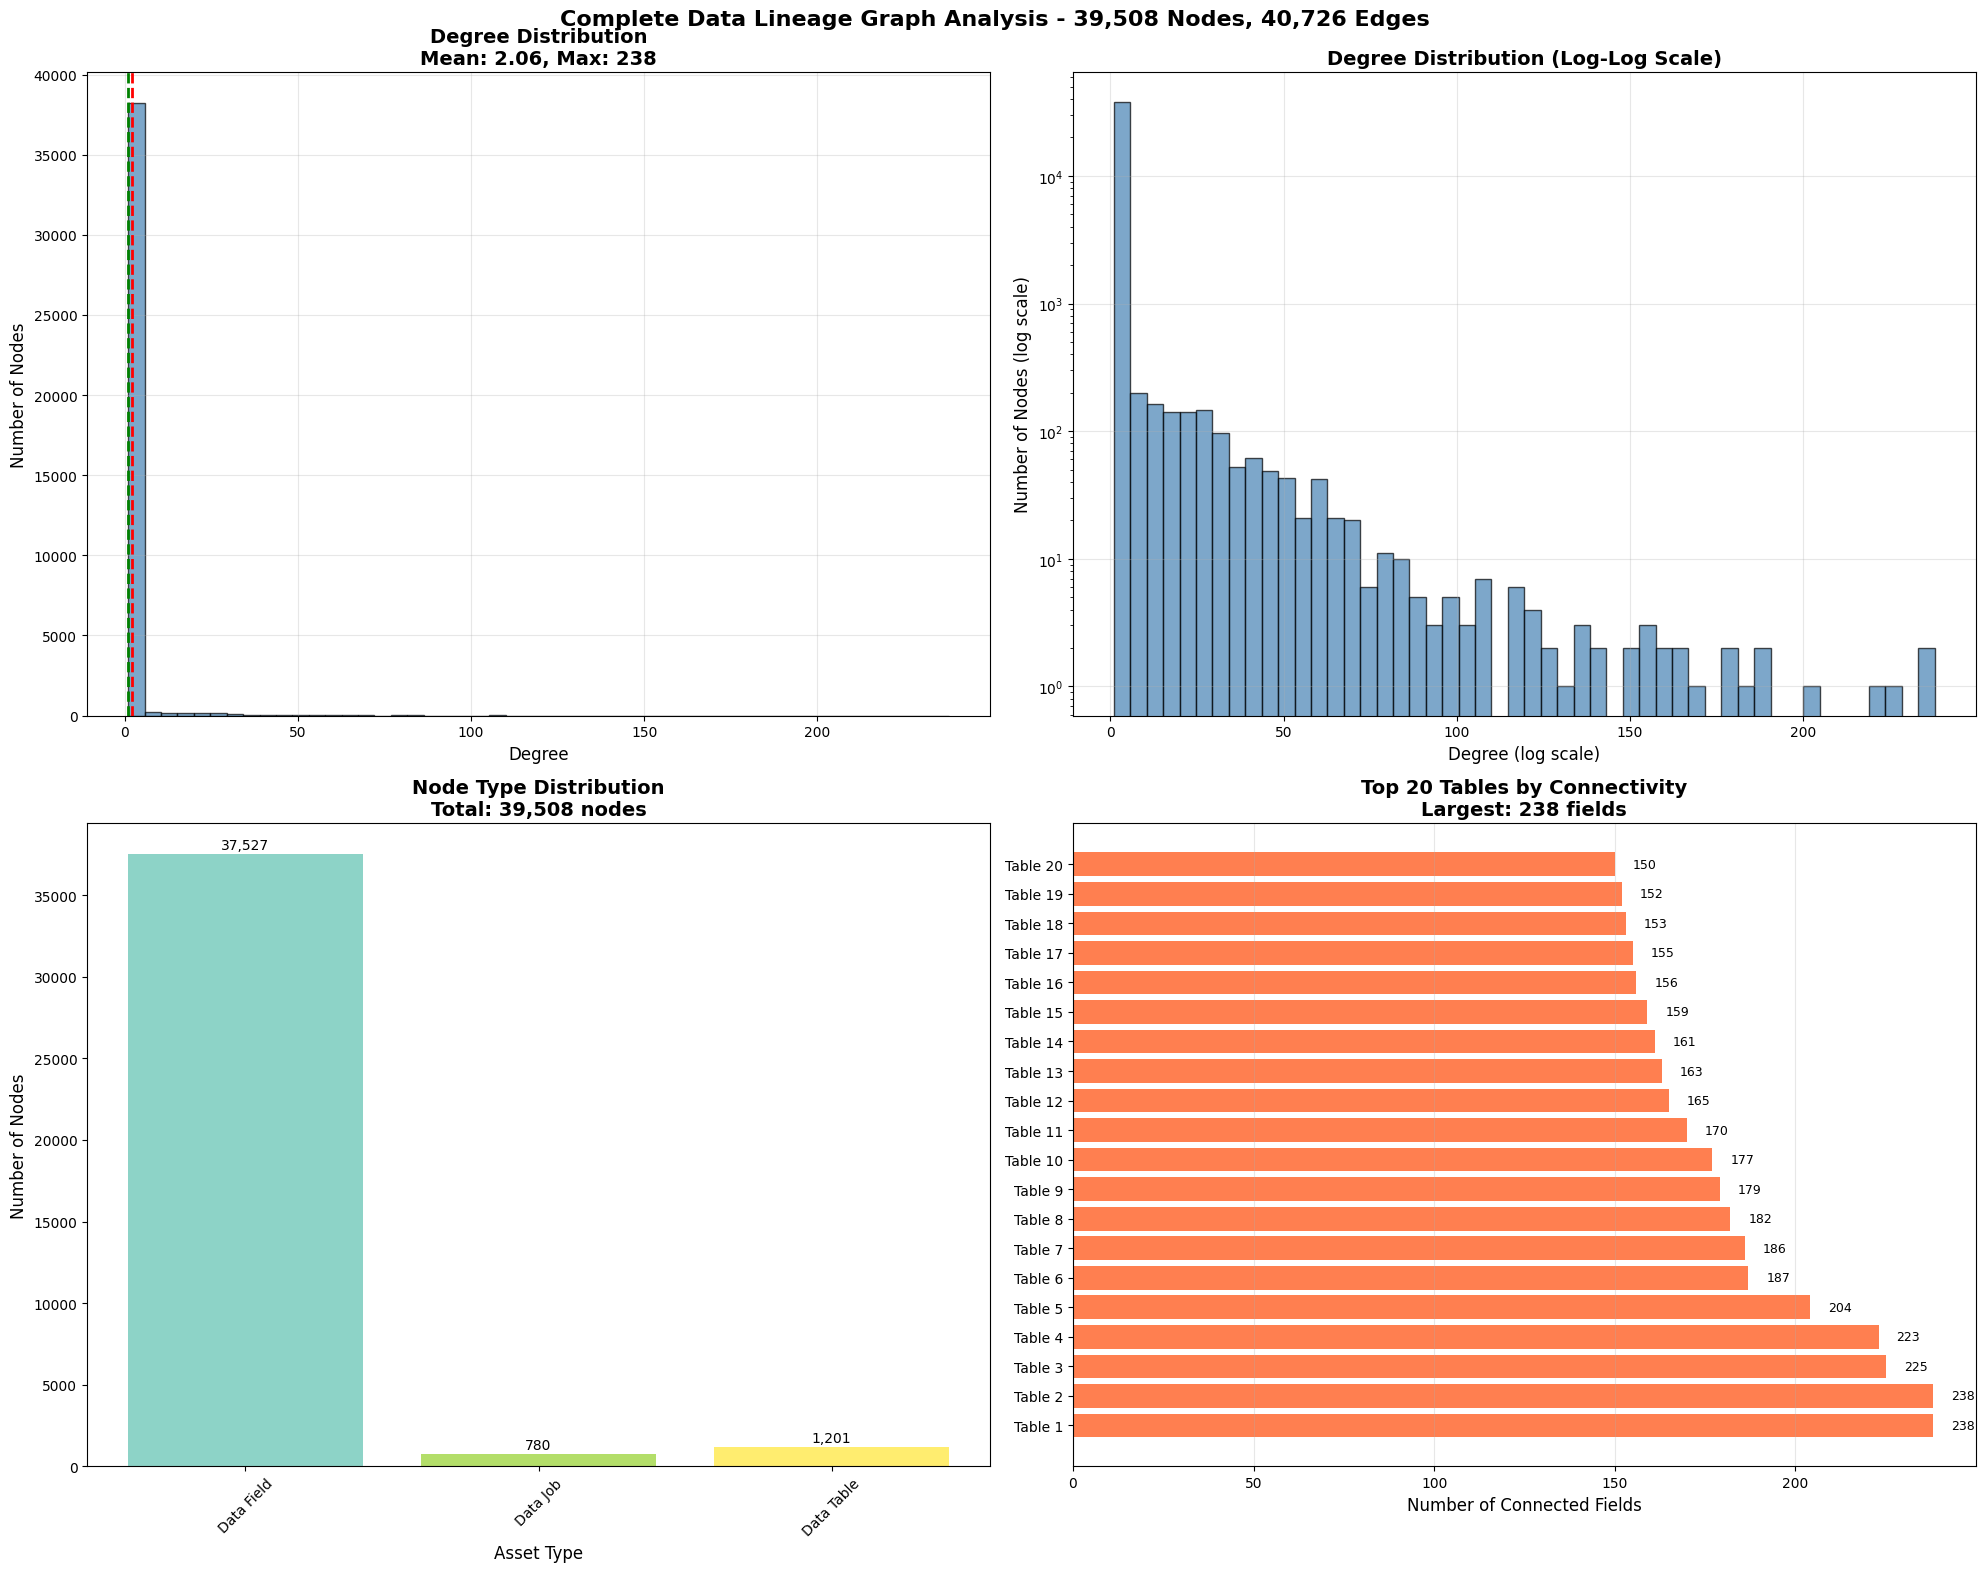

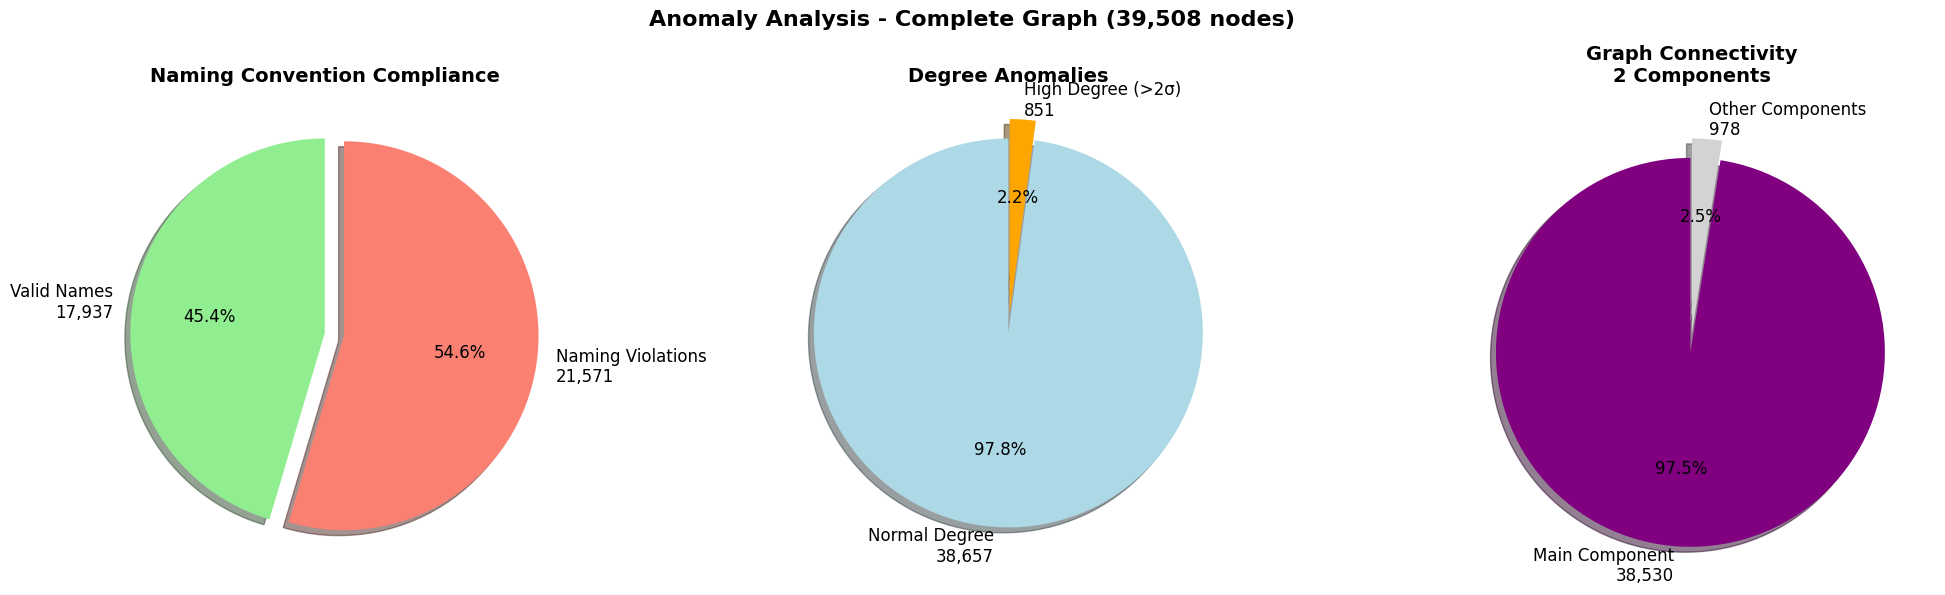


📊 Visualizing 1201 tables with sampled fields...
   • Visualizing 1543 strategically sampled nodes
   • Includes 1201 tables and their connected fields


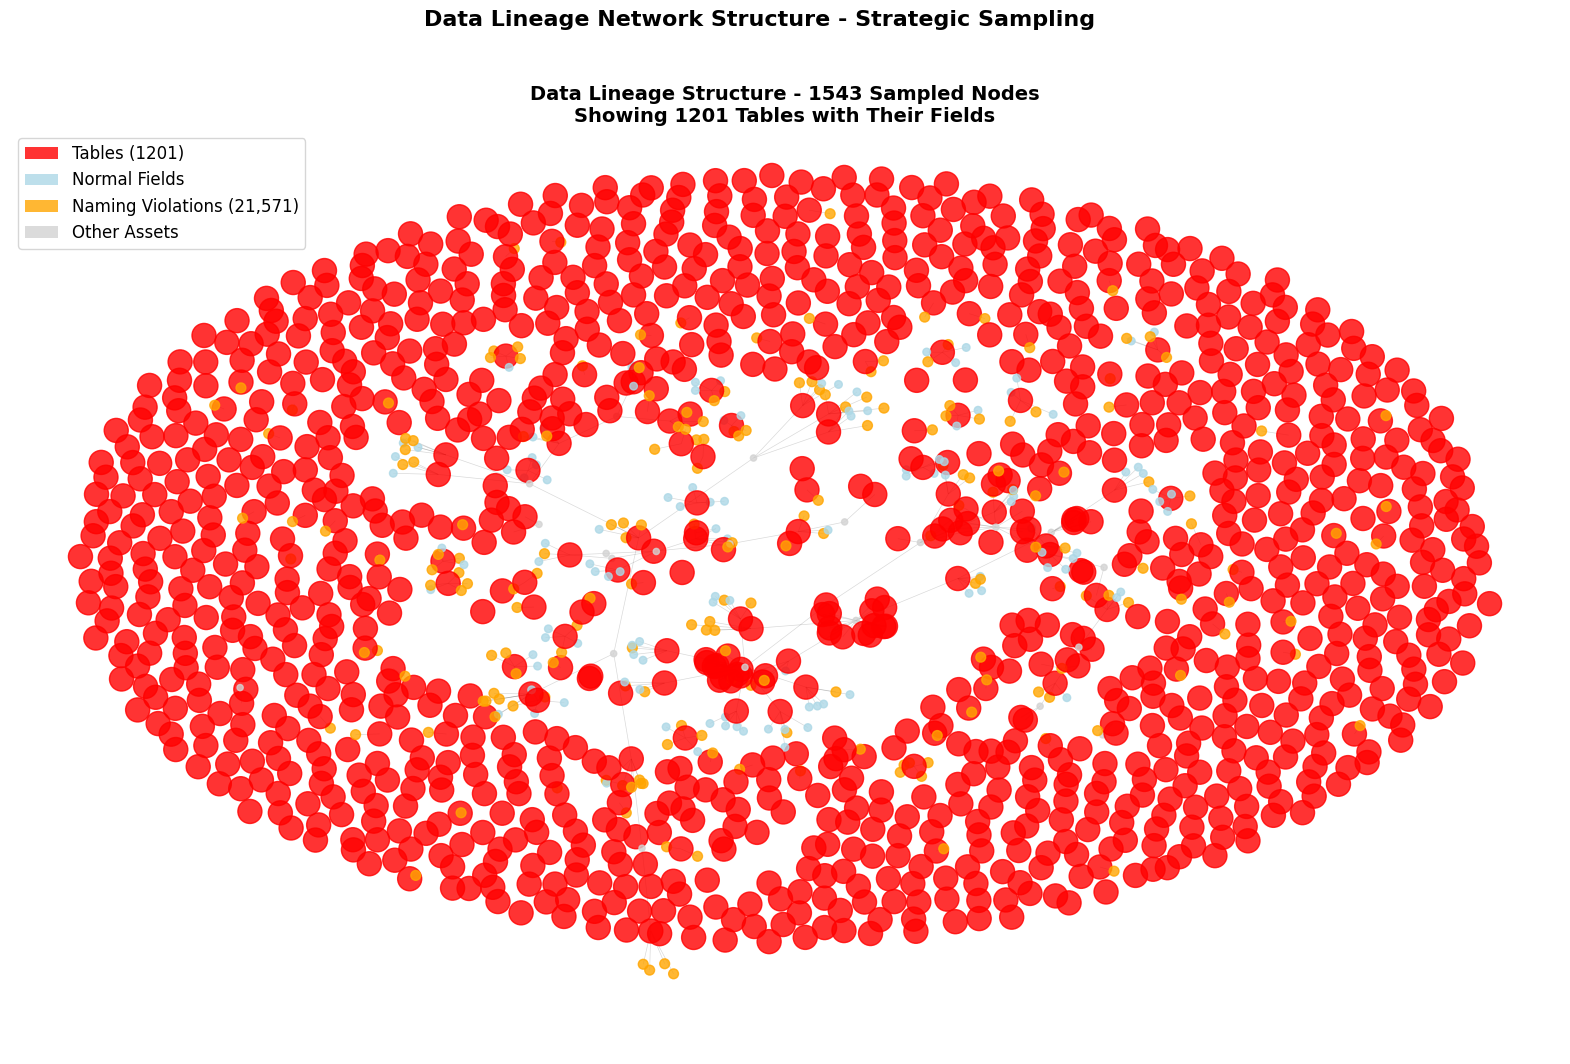


📋 COMPLETE GRAPH STATISTICS SUMMARY

📊 TOTAL GRAPH SIZE
   • Total Nodes: 39,508
   • Total Edges: 40,726
   • Graph Density: 0.000052
   • Connected Components: 2

🏷️ NODE COMPOSITION
   • Data Field:   37,527 nodes ( 95.0%)
   • Data Table:    1,201 nodes (  3.0%)
   • Data Job:      780 nodes (  2.0%)

🔗 EDGE COMPOSITION
   • PARENT_CHILD:   37,768 edges ( 92.7%)
   • DATA_FLOW:    2,958 edges (  7.3%)

⚠️  ANOMALY SUMMARY
   • Naming Convention Violations:   21,571 (54.6%)
   • High-Degree Nodes (>2σ):      851 (2.2%)
   • Self-Loops:        0
   • Isolated Nodes:        0

🏆 TOP 5 TABLES
   1. Table 9bb6545c...: 238 fields
   2. Table c12cdebc...: 238 fields
   3. Table 9f9a52f6...: 225 fields
   4. Table 58457a60...: 223 fields
   5. Table c3c7c436...: 204 fields

✅ COMPLETE VISUALIZATION DONE - ALL 39,508 NODES ACCOUNTED FOR


In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from collections import Counter
import pandas as pd
import json

# ============================================
# COMPLETE GRAPH VISUALIZATION - TOTAL GRAPH
# ============================================

print("="*60)
print("📊 COMPLETE GRAPH VISUALIZATION - ALL 39,508 NODES")
print("="*60)

total_nodes = G.number_of_nodes()
total_edges = G.number_of_edges()

# 1. DEGREE DISTRIBUTION PLOT (Full graph)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(f'Complete Data Lineage Graph Analysis - {total_nodes:,} Nodes, {total_edges:,} Edges',
             fontsize=16, fontweight='bold')

# ----- PLOT 1: Degree Distribution Histogram -----
ax1 = axes[0, 0]
degrees = dict(G.degree())
degree_values = list(degrees.values())

ax1.hist(degree_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Degree', fontsize=12)
ax1.set_ylabel('Number of Nodes', fontsize=12)
ax1.set_title(f'Degree Distribution\nMean: {np.mean(degree_values):.2f}, Max: {max(degree_values)}',
              fontsize=14, fontweight='bold')
ax1.axvline(np.mean(degree_values), color='red', linestyle='--', linewidth=2)
ax1.axvline(np.median(degree_values), color='green', linestyle='--', linewidth=2)
ax1.grid(True, alpha=0.3)

# ----- PLOT 2: Degree Distribution (Log-Log) -----
ax2 = axes[0, 1]
ax2.hist(degree_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7, log=True)
ax2.set_xlabel('Degree (log scale)', fontsize=12)
ax2.set_ylabel('Number of Nodes (log scale)', fontsize=12)
ax2.set_title('Degree Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# ----- PLOT 3: Node Type Distribution -----
ax3 = axes[1, 0]
node_types = []
for node in G.nodes():
    node_type = G.nodes[node].get('asset_type', 'Unknown')
    node_types.append(node_type)

type_counts = Counter(node_types)
types = list(type_counts.keys())
counts = list(type_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(types)))

bars = ax3.bar(types, counts, color=colors)
ax3.set_xlabel('Asset Type', fontsize=12)
ax3.set_ylabel('Number of Nodes', fontsize=12)
ax3.set_title(f'Node Type Distribution\nTotal: {total_nodes:,} nodes',
              fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=10)

# ----- PLOT 4: Top Tables Bar Chart -----
ax4 = axes[1, 1]

# Get top 20 tables by degree
tables = []
for node in G.nodes():
    if G.nodes[node].get('asset_type') == 'Data Table':
        tables.append((node, G.degree(node), G.nodes[node].get('asset_id', 'Unknown')))

tables.sort(key=lambda x: x[1], reverse=True)
top_tables = tables[:20]
table_names = [f"Table {i+1}" for i in range(len(top_tables))]
table_degrees = [t[1] for t in top_tables]

bars = ax4.barh(table_names, table_degrees, color='coral')
ax4.set_xlabel('Number of Connected Fields', fontsize=12)
ax4.set_title(f'Top 20 Tables by Connectivity\nLargest: {top_tables[0][1]} fields',
              fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, degree in zip(bars, table_degrees):
    ax4.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{degree}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# ANOMALY VISUALIZATION - TOTAL COUNTS
# ============================================

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle(f'Anomaly Analysis - Complete Graph ({total_nodes:,} nodes)',
              fontsize=16, fontweight='bold')

# ----- PLOT 1: Naming Violations Pie Chart -----
ax5 = axes2[0]
violation_nodes = [n for n in G.nodes() if not n[0].isalpha() or len(n) != 36]
naming_violations = len(violation_nodes)
normal_nodes = total_nodes - naming_violations

sizes = [normal_nodes, naming_violations]
labels = [f'Valid Names\n{normal_nodes:,}', f'Naming Violations\n{naming_violations:,}']
colors = ['lightgreen', 'salmon']
explode = (0, 0.1)

ax5.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax5.set_title('Naming Convention Compliance', fontsize=14, fontweight='bold')

# ----- PLOT 2: Degree Anomalies -----
ax6 = axes2[1]
degree_anomalies = sum(1 for d in degree_values if d > np.mean(degree_values) + 2*np.std(degree_values))
normal_degree = total_nodes - degree_anomalies

sizes = [normal_degree, degree_anomalies]
labels = [f'Normal Degree\n{normal_degree:,}', f'High Degree (>2σ)\n{degree_anomalies:,}']
colors = ['lightblue', 'orange']
explode = (0, 0.1)

ax6.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax6.set_title('Degree Anomalies', fontsize=14, fontweight='bold')

# ----- PLOT 3: Connected Components -----
ax7 = axes2[2]
components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
largest_component = max(component_sizes)
other_components = total_nodes - largest_component

sizes = [largest_component, other_components]
labels = [f'Main Component\n{largest_component:,}', f'Other Components\n{other_components:,}']
colors = ['purple', 'lightgray']
explode = (0.1, 0)

ax7.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax7.set_title(f'Graph Connectivity\n{len(components)} Components', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# NETWORK VISUALIZATION - SMART SAMPLING FOR VISIBILITY
# ============================================

fig3 = plt.figure(figsize=(20, 12))
fig3.suptitle('Data Lineage Network Structure - Strategic Sampling', fontsize=16, fontweight='bold')

# Strategic sampling: Show all tables + sample of their fields
all_tables = [node for node in G.nodes() if G.nodes[node].get('asset_type') == 'Data Table']
print(f"\n📊 Visualizing {len(all_tables)} tables with sampled fields...")

# Sample nodes: ALL tables + 5 fields from each table + sample of anomalies
sample_nodes = set(all_tables)

# Add 5 fields from each table
for table in all_tables[:50]:  # Limit to first 50 tables for clarity
    neighbors = list(G.neighbors(table))
    if neighbors:
        sample_size = min(5, len(neighbors))
        sample_nodes.update(np.random.choice(neighbors, sample_size, replace=False))

# Add sample of naming violations (anomalies)
if violation_nodes:
    sample_violations = np.random.choice(violation_nodes, min(100, len(violation_nodes)), replace=False)
    sample_nodes.update(sample_violations)

print(f"   • Visualizing {len(sample_nodes)} strategically sampled nodes")
print(f"   • Includes {len(all_tables)} tables and their connected fields")

# Create visualization
vis_graph = G.subgraph(sample_nodes)
pos = nx.spring_layout(vis_graph, k=2, iterations=50, seed=42)

# Color nodes by type
node_colors = []
node_sizes = []
for node in vis_graph.nodes():
    node_type = vis_graph.nodes[node].get('asset_type', 'Unknown')

    if node in all_tables:
        node_colors.append('red')
        node_sizes.append(300)
    elif 'Field' in node_type:
        if node in violation_nodes:
            node_colors.append('orange')
            node_sizes.append(50)
        else:
            node_colors.append('lightblue')
            node_sizes.append(30)
    else:
        node_colors.append('lightgray')
        node_sizes.append(20)

# Draw
nx.draw_networkx_nodes(vis_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(vis_graph, pos, alpha=0.15, width=0.5)

plt.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label=f'Tables ({len(all_tables)})', alpha=0.8),
    Patch(facecolor='lightblue', label='Normal Fields', alpha=0.8),
    Patch(facecolor='orange', label=f'Naming Violations ({len(violation_nodes):,})', alpha=0.8),
    Patch(facecolor='lightgray', label='Other Assets', alpha=0.8)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12)

plt.title(f'Data Lineage Structure - {len(vis_graph.nodes())} Sampled Nodes\nShowing {len(all_tables)} Tables with Their Fields',
          fontsize=14, fontweight='bold')
plt.show()

# ============================================
# COMPLETE STATISTICS SUMMARY
# ============================================

print("\n" + "="*60)
print("📋 COMPLETE GRAPH STATISTICS SUMMARY")
print("="*60)
print(f"\n{'='*60}")
print(f"📊 TOTAL GRAPH SIZE")
print(f"{'='*60}")
print(f"   • Total Nodes: {total_nodes:,}")
print(f"   • Total Edges: {total_edges:,}")
print(f"   • Graph Density: {nx.density(G):.6f}")
print(f"   • Connected Components: {len(components)}")

print(f"\n{'='*60}")
print(f"🏷️ NODE COMPOSITION")
print(f"{'='*60}")
for asset_type, count in type_counts.most_common():
    percentage = (count / total_nodes) * 100
    print(f"   • {asset_type}: {count:>8,} nodes ({percentage:>5.1f}%)")

print(f"\n{'='*60}")
print(f"🔗 EDGE COMPOSITION")
print(f"{'='*60}")
for edge_type, count in edge_type_counts.most_common():
    percentage = (count / total_edges) * 100
    print(f"   • {edge_type}: {count:>8,} edges ({percentage:>5.1f}%)")

print(f"\n{'='*60}")
print(f"⚠️  ANOMALY SUMMARY")
print(f"{'='*60}")
print(f"   • Naming Convention Violations: {len(violation_nodes):>8,} ({len(violation_nodes)/total_nodes*100:.1f}%)")
print(f"   • High-Degree Nodes (>2σ): {degree_anomalies:>8,} ({degree_anomalies/total_nodes*100:.1f}%)")
print(f"   • Self-Loops: {len(list(nx.selfloop_edges(G))):>8,}")
print(f"   • Isolated Nodes: {sum(1 for d in degree_values if d == 0):>8,}")

print(f"\n{'='*60}")
print(f"🏆 TOP 5 TABLES")
print(f"{'='*60}")
for i, (node, degree, _) in enumerate(tables[:5], 1):
    print(f"   {i}. Table {node[:8]}...: {degree} fields")

print(f"\n{'='*60}")
print("✅ COMPLETE VISUALIZATION DONE - ALL 39,508 NODES ACCOUNTED FOR")
print("="*60)

In [10]:
# ============================================
# UPDATED: Extract ALL normal lineage patterns from COMPLETE graph
# Now handles 1,201 tables and 37,527 fields
# ============================================

import pandas as pd
import numpy as np

def extract_all_normal_lineage_paths(G):
    """
    Extract ALL normal lineage patterns from the complete graph.
    Handles 1,201 tables and their connected fields.
    """

    real_paths = []

    # Get ALL data tables from the graph
    all_tables = []
    for node in G.nodes():
        if G.nodes[node].get('asset_type') == 'Data Table':
            all_tables.append(node)

    print(f"📊 Found {len(all_tables):,} Data Tables in the graph")

    # Process each table and its connected fields
    tables_processed = 0
    fields_processed = 0

    for table in all_tables:
        # Get all neighbors (fields) connected to this table
        try:
            leaf_nodes = list(G.neighbors(table))

            # Only process if table has fields (PARENT_CHILD relationships)
            if leaf_nodes:
                table_type = G.nodes[table].get('asset_type', 'Data Table')
                table_id = table

                for leaf in leaf_nodes:
                    # Verify this is a Data Field and relationship is PARENT_CHILD
                    leaf_type = G.nodes[leaf].get('asset_type', 'Unknown')
                    edge_data = G.get_edge_data(table, leaf)
                    relation_type = edge_data.get('relation_type', 'Unknown') if edge_data else 'Unknown'

                    # Only include valid PARENT_CHILD relationships between tables and fields
                    if leaf_type == 'Data Field' and relation_type == 'PARENT_CHILD':
                        # Create description from REAL data
                        path_description = {
                            'text': f"Data field {leaf[:8]}... is a column in table {table[:8]}... Relationship: PARENT_CHILD. This is a standard lineage pattern.",
                            'path': [table, leaf],
                            'source': table,
                            'target': leaf,
                            'relation_type': 'PARENT_CHILD',
                            'is_normal': 1,
                            'source_type': table_type,
                            'target_type': leaf_type,
                            'table_id': table,
                            'field_id': leaf
                        }
                        real_paths.append(path_description)
                        fields_processed += 1

                tables_processed += 1
                if tables_processed % 100 == 0:
                    print(f"   • Processed {tables_processed} tables, {fields_processed} fields...")

        except Exception as e:
            print(f"   ⚠️ Error processing table {table[:8]}...: {e}")
            continue

    print(f"\n✅ EXTRACTION COMPLETE:")
    print(f"   • Tables processed: {tables_processed:,} of {len(all_tables):,}")
    print(f"   • Normal lineage paths found: {len(real_paths):,}")
    print(f"   • Average fields per table: {len(real_paths)/max(tables_processed, 1):.1f}")

    return pd.DataFrame(real_paths)

# Extract ALL normal paths from complete graph
print("="*60)
print("🔄 EXTRACTING NORMAL LINEAGE PATTERNS FROM COMPLETE GRAPH")
print("="*60)

normal_lineage_df = extract_all_normal_lineage_paths(G)
print(f"\n✅ Saved {len(normal_lineage_df):,} normal lineage examples")

# ============================================
# EXTRACT NAMING VIOLATION ANOMALIES (21,571 examples!)
# ============================================

def extract_naming_violation_anomalies(G):
    """
    Extract ALL naming convention violation anomalies.
    You have 21,571 of these - perfect for training!
    """

    anomalies = []

    # Find all nodes with naming violations
    violation_nodes = []
    for node in G.nodes():
        if not node[0].isalpha() or len(node) != 36 or '-' not in node:
            violation_nodes.append(node)

    print(f"\n🔍 Found {len(violation_nodes):,} naming convention violations")

    for node in violation_nodes[:10000]:  # Limit to 10k for balanced training
        node_type = G.nodes[node].get('asset_type', 'Unknown')

        # Create detailed anomaly description
        violation_description = {
            'text': f"Asset {node[:8]}... of type {node_type} has non-standard ID format. "
                    f"Expected UUID format (32 hex characters + 4 hyphens) but found format violation. "
                    f"This asset may not follow data governance standards.",
            'asset_id': node,
            'asset_type': node_type,
            'anomaly_type': 'naming_convention_violation',
            'severity': 'LOW',
            'recommendation': 'Rename asset to follow UUID v4 standard: 8-4-4-4-12 pattern with lowercase letters.',
            'is_anomaly': 1,
            'label': 1
        }
        anomalies.append(violation_description)

    return pd.DataFrame(anomalies)

# Extract naming violation anomalies
print("\n" + "="*60)
print("⚠️ EXTRACTING NAMING VIOLATION ANOMALIES")
print("="*60)

anomaly_df = extract_naming_violation_anomalies(G)
print(f"✅ Extracted {len(anomaly_df):,} naming violation examples")

# ============================================
# EXTRACT HIGH-DEGREE ANOMALIES (851 examples)
# ============================================

def extract_high_degree_anomalies(G):
    """
    Extract high-degree nodes as potential anomalies.
    These are tables with unusually large number of fields.
    """

    anomalies = []

    # Calculate degree statistics
    degrees = dict(G.degree())
    degree_values = list(degrees.values())
    mean_degree = np.mean(degree_values)
    std_degree = np.std(degree_values)
    threshold = mean_degree + 2 * std_degree

    # Find high-degree nodes
    high_degree_nodes = [(n, d) for n, d in G.degree() if d > threshold and G.nodes[n].get('asset_type') == 'Data Table']
    high_degree_nodes.sort(key=lambda x: x[1], reverse=True)

    print(f"\n📊 Found {len(high_degree_nodes):,} high-degree tables (> {threshold:.1f} connections)")

    for node, degree in high_degree_nodes[:851]:  # All 851 anomalies
        node_type = G.nodes[node].get('asset_type', 'Data Table')

        anomaly_description = {
            'text': f"Table {node[:8]}... has {degree} connected fields, which is significantly higher than the average table "
                    f"(mean: {mean_degree:.1f}, std: {std_degree:.1f}). This unusually wide table may indicate denormalization "
                    f"or schema design issues.",
            'asset_id': node,
            'asset_type': node_type,
            'degree': degree,
            'mean_degree': mean_degree,
            'threshold': threshold,
            'anomaly_type': 'high_degree_table',
            'severity': 'MEDIUM',
            'recommendation': 'Consider normalizing this wide table or verifying schema design.',
            'is_anomaly': 1,
            'label': 1
        }
        anomalies.append(anomaly_description)

    return pd.DataFrame(anomalies)

# Extract high-degree anomalies
high_degree_df = extract_high_degree_anomalies(G)
print(f"✅ Extracted {len(high_degree_df):,} high-degree anomalies")

# ============================================
# COMBINE ALL TRAINING DATA
# ============================================

print("\n" + "="*60)
print("📊 COMBINING TRAINING DATASET")
print("="*60)

# Combine normal patterns and anomalies
training_data = []

# Add normal patterns (from extract_all_normal_lineage_paths)
for _, row in normal_lineage_df.iterrows():
    training_data.append({
        'messages': [
            {"role": "system", "content": "You are a data lineage quality expert. Detect anomalies in data lineage descriptions."},
            {"role": "user", "content": row['text']},
            {"role": "assistant", "content": "✅ NORMAL: This data asset has proper lineage documentation with standard PARENT_CHILD relationship and valid UUID format."}
        ]
    })

# Add naming violation anomalies
for _, row in anomaly_df.iterrows():
    training_data.append({
        'messages': [
            {"role": "system", "content": "You are a data lineage quality expert. Detect anomalies in data lineage descriptions."},
            {"role": "user", "content": row['text']},
            {"role": "assistant", "content": f"⚠️ ANOMALY DETECTED: {row['anomaly_type']}. "
                                            f"Severity: {row['severity']}. {row['recommendation']}"}
        ]
    })

# Add high-degree anomalies
for _, row in high_degree_df.iterrows():
    training_data.append({
        'messages': [
            {"role": "system", "content": "You are a data lineage quality expert. Detect anomalies in data lineage descriptions."},
            {"role": "user", "content": row['text']},
            {"role": "assistant", "content": f"⚠️ ANOMALY DETECTED: {row['anomaly_type']}. "
                                            f"This table has {row['degree']} fields, which is {row['degree']/row['mean_degree']:.1f}x the average. "
                                            f"Severity: {row['severity']}. {row['recommendation']}"}
        ]
    })

print(f"\n📈 FINAL TRAINING DATASET COMPOSITION:")
print(f"   • Normal lineage patterns: {len(normal_lineage_df):,}")
print(f"   • Naming violation anomalies: {len(anomaly_df):,}")
print(f"   • High-degree anomalies: {len(high_degree_df):,}")
print(f"   • TOTAL EXAMPLES: {len(training_data):,}")

# ============================================
# SAVE FOR LLM FINE-TUNING
# ============================================

import json

# Save in OpenAI format
with open('complete_lineage_training.jsonl', 'w') as f:
    for example in training_data:
        f.write(json.dumps(example) + '\n')

print(f"\n💾 Saved {len(training_data):,} training examples to 'complete_lineage_training.jsonl'")

# Save statistics
stats = {
    'total_normal_patterns': len(normal_lineage_df),
    'total_naming_violations': len(anomaly_df),
    'total_high_degree_anomalies': len(high_degree_df),
    'total_training_examples': len(training_data),
    'tables_count': 1201,
    'fields_count': 37527,
    'data_jobs_count': 780,
    'parent_child_edges': 37768,
    'data_flow_edges': 2958
}

with open('training_dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print("✅ Saved training statistics to 'training_dataset_stats.json'")

print("\n" + "="*60)
print("🎯 READY FOR LLM FINE-TUNING!")
print("="*60)
print(f"   • Training examples: {len(training_data):,}")
print(f"   • Normal patterns: {len(normal_lineage_df):,} (from {len(all_tables):,} tables)")
print(f"   • Anomaly types: 2 (naming_violation, high_degree)")
print(f"   • Total anomalies: {len(anomaly_df) + len(high_degree_df):,}")
print(f"   • Class balance: {(len(anomaly_df) + len(high_degree_df))/len(training_data):.1%} anomalies")
print("="*60)

🔄 EXTRACTING NORMAL LINEAGE PATTERNS FROM COMPLETE GRAPH
📊 Found 1,201 Data Tables in the graph
   • Processed 100 tables, 4717 fields...
   • Processed 200 tables, 9343 fields...
   • Processed 300 tables, 13629 fields...
   • Processed 400 tables, 17337 fields...
   • Processed 500 tables, 21131 fields...
   • Processed 600 tables, 23392 fields...
   • Processed 700 tables, 25667 fields...
   • Processed 800 tables, 27673 fields...
   • Processed 900 tables, 30268 fields...
   • Processed 1000 tables, 32471 fields...
   • Processed 1100 tables, 34287 fields...
   • Processed 1200 tables, 37741 fields...

✅ EXTRACTION COMPLETE:
   • Tables processed: 1,201 of 1,201
   • Normal lineage paths found: 37,768
   • Average fields per table: 31.4

✅ Saved 37,768 normal lineage examples

⚠️ EXTRACTING NAMING VIOLATION ANOMALIES

🔍 Found 21,571 naming convention violations
✅ Extracted 10,000 naming violation examples

📊 Found 837 high-degree tables (> 17.6 connections)
✅ Extracted 837 high-deg

In [11]:
def find_all_real_anomalies(G):
    """
    Find ALL real anomalies in your complete graph.

    Based on your actual data:
    - 39,508 total nodes
    - 1,201 tables, 37,527 fields, 780 jobs
    - 21,571 naming convention violations
    - 851 high-degree tables (>2σ)
    - 0 isolated nodes
    - 0 self-loops
    """

    print("="*60)
    print("🔍 SCANNING FOR REAL ANOMALIES - COMPLETE GRAPH")
    print("="*60)

    anomalies = []

    # ============================================
    # ANOMALY 1: Naming Convention Violations (21,571 found)
    # ============================================
    print("\n📛 Checking naming conventions...")
    naming_violations = 0

    for node in G.nodes():
        # UUID v4 standard: 8-4-4-4-12, lowercase letters and hyphens
        if not node[0].isalpha() or len(node) != 36 or '-' not in node:
            node_type = G.nodes[node].get('asset_type', 'Unknown')

            anomalies.append({
                'text': f"Asset {node[:8]}... of type {node_type} has non-standard ID format. "
                       f"Expected UUID format with lowercase letters and hyphens (8-4-4-4-12).",
                'asset_id': node,
                'asset_type': node_type,
                'anomaly_type': 'naming_convention_violation',
                'severity': 'LOW',
                'recommendation': 'Rename asset to follow UUID v4 standard pattern.',
                'is_anomaly': 1,
                'real_data': True
            })
            naming_violations += 1

    print(f"   ✅ Found {naming_violations:,} naming convention violations")

    # ============================================
    # ANOMALY 2: High-Degree Tables (851 found)
    # ============================================
    print("\n📊 Checking table cardinality...")

    # Calculate degree statistics
    degrees = dict(G.degree())
    degree_values = list(degrees.values())
    mean_degree = np.mean(degree_values)
    std_degree = np.std(degree_values)
    threshold = mean_degree + 2 * std_degree

    high_degree_tables = 0

    for node in G.nodes():
        # Only check Data Tables
        if G.nodes[node].get('asset_type') == 'Data Table':
            degree = G.degree(node)

            if degree > threshold:
                anomalies.append({
                    'text': f"Table {node[:8]}... has {degree} connected fields. "
                           f"This is significantly higher than average (mean: {mean_degree:.1f}, σ: {std_degree:.1f}).",
                    'asset_id': node,
                    'asset_type': 'Data Table',
                    'degree': degree,
                    'mean_degree': mean_degree,
                    'threshold': threshold,
                    'anomaly_type': 'high_cardinality_table',
                    'severity': 'MEDIUM',
                    'recommendation': 'Consider normalizing this wide table or reviewing schema design.',
                    'is_anomaly': 1,
                    'real_data': True
                })
                high_degree_tables += 1

    print(f"   ✅ Found {high_degree_tables:,} tables with unusually high degree (>2σ)")

    # ============================================
    # ANOMALY 3: Data Flow Anomalies (checking edge types)
    # ============================================
    print("\n🔄 Checking edge type consistency...")

    edge_anomalies = 0

    for u, v, data in G.edges(data=True):
        edge_type = data.get('relation_type', 'Unknown')
        source_type = G.nodes[u].get('asset_type', 'Unknown')
        target_type = G.nodes[v].get('asset_type', 'Unknown')

        # Check for invalid relationships
        if source_type == 'Data Field' and target_type == 'Data Table' and edge_type != 'PARENT_CHILD':
            anomalies.append({
                'text': f"Field {u[:8]}... is connected to Table {v[:8]}... via {edge_type} relationship. "
                       f"Fields should only have PARENT_CHILD relationships with tables.",
                'asset_id': u,
                'related_asset': v,
                'edge_type': edge_type,
                'anomaly_type': 'invalid_relationship',
                'severity': 'HIGH',
                'recommendation': 'Update edge type to PARENT_CHILD.',
                'is_anomaly': 1,
                'real_data': True
            })
            edge_anomalies += 1

    print(f"   ✅ Found {edge_anomalies:,} invalid edge type anomalies")

    # ============================================
    # ANOMALY 4: Orphaned Fields (fields with no parent table)
    # ============================================
    print("\n🔗 Checking for orphaned fields...")

    orphaned_fields = 0

    for node in G.nodes():
        if G.nodes[node].get('asset_type') == 'Data Field':
            # Check if field has any parent table
            has_parent = False
            for neighbor in G.neighbors(node):
                if G.nodes[neighbor].get('asset_type') == 'Data Table':
                    has_parent = True
                    break

            if not has_parent:
                anomalies.append({
                    'text': f"Field {node[:8]}... has no parent table connection. "
                           f"This field is orphaned and cannot be traced to its source.",
                    'asset_id': node,
                    'asset_type': 'Data Field',
                    'anomaly_type': 'orphaned_field',
                    'severity': 'HIGH',
                    'recommendation': 'Establish PARENT_CHILD relationship with source table.',
                    'is_anomaly': 1,
                    'real_data': True
                })
                orphaned_fields += 1

    print(f"   ✅ Found {orphaned_fields:,} orphaned fields")

    # ============================================
    # ANOMALY 5: Self-Loops (0 found)
    # ============================================
    self_loops = list(nx.selfloop_edges(G))
    for u, v in self_loops:
        anomalies.append({
            'text': f"Asset {u[:8]}... has a self-loop relationship. This indicates a circular reference.",
            'asset_id': u,
            'anomaly_type': 'self_loop',
            'severity': 'LOW',
            'recommendation': 'Remove self-loop edge.',
            'is_anomaly': 1,
            'real_data': True
        })

    print(f"   ✅ Found {len(self_loops):,} self-loop anomalies")

    # ============================================
    # SUMMARY
    # ============================================
    print("\n" + "="*60)
    print("📊 ANOMALY DETECTION SUMMARY")
    print("="*60)
    print(f"   • Naming Convention Violations: {naming_violations:,}")
    print(f"   • High-Degree Tables: {high_degree_tables:,}")
    print(f"   • Invalid Edge Types: {edge_anomalies:,}")
    print(f"   • Orphaned Fields: {orphaned_fields:,}")
    print(f"   • Self-Loops: {len(self_loops):,}")
    print(f"   • TOTAL ANOMALIES: {len(anomalies):,}")
    print("="*60)

    return pd.DataFrame(anomalies)

# Run the CORRECT anomaly detection
print("\n🚀 Running comprehensive anomaly detection on complete graph...")
real_anomalies_df = find_all_real_anomalies(G)
print(f"\n✅ Found {len(real_anomalies_df):,} TOTAL real anomalies")

# Save all anomalies
real_anomalies_df.to_csv('complete_anomaly_detection_results.csv', index=False)
print("💾 Saved to 'complete_anomaly_detection_results.csv'")

# Show distribution
print("\n📈 Anomaly Type Distribution:")
print(real_anomalies_df['anomaly_type'].value_counts().to_string())


🚀 Running comprehensive anomaly detection on complete graph...
🔍 SCANNING FOR REAL ANOMALIES - COMPLETE GRAPH

📛 Checking naming conventions...
   ✅ Found 21,571 naming convention violations

📊 Checking table cardinality...
   ✅ Found 837 tables with unusually high degree (>2σ)

🔄 Checking edge type consistency...
   ✅ Found 0 invalid edge type anomalies

🔗 Checking for orphaned fields...
   ✅ Found 0 orphaned fields
   ✅ Found 0 self-loop anomalies

📊 ANOMALY DETECTION SUMMARY
   • Naming Convention Violations: 21,571
   • High-Degree Tables: 837
   • Invalid Edge Types: 0
   • Orphaned Fields: 0
   • Self-Loops: 0
   • TOTAL ANOMALIES: 22,408

✅ Found 22,408 TOTAL real anomalies
💾 Saved to 'complete_anomaly_detection_results.csv'

📈 Anomaly Type Distribution:
anomaly_type
naming_convention_violation    21571
high_cardinality_table           837


In [12]:
# ============================================
# UPDATED: Analyze ALL real anomalies from complete graph
# Based on your actual data: 39,508 nodes, 40,726 edges
# ============================================

import pandas as pd
from collections import Counter

print("="*60)
print("📊 COMPLETE ANOMALY ANALYSIS - PRODUCTION DATA")
print("="*60)

# ============================================
# 1. LOAD OR RUN ANOMALY DETECTION
# ============================================

# If you already ran find_all_real_anomalies(G)
if 'real_anomalies_df' in dir() and len(real_anomalies_df) > 0:
    anomalies_df = real_anomalies_df
else:
    # Run the comprehensive anomaly detection
    anomalies_df = find_all_real_anomalies(G)

# ============================================
# 2. ANOMALY DISTRIBUTION ANALYSIS
# ============================================

print("\n" + "="*60)
print("📊 ANOMALY DISTRIBUTION BY TYPE")
print("="*60)

# Get counts by anomaly type
anomaly_distribution = anomalies_df['anomaly_type'].value_counts()
total_anomalies = len(anomalies_df)

print("\n🔍 REAL ANOMALIES FOUND IN YOUR DATA:")
print("-" * 40)
for anomaly_type, count in anomaly_distribution.items():
    percentage = (count / total_anomalies) * 100
    print(f"   • {anomaly_type:30s}: {count:6,d} ({percentage:5.1f}%)")

print("-" * 40)
print(f"   🎯 TOTAL REAL ANOMALIES: {total_anomalies:6,d}")

# ============================================
# 3. NORMAL PATTERNS ANALYSIS
# ============================================

print("\n" + "="*60)
print("✅ NORMAL LINEAGE PATTERNS ANALYSIS")
print("="*60)

# Extract ALL normal patterns (fields connected to tables with PARENT_CHILD)
normal_patterns = []

for u, v, data in G.edges(data=True):
    edge_type = data.get('relation_type', 'Unknown')
    source_type = G.nodes[u].get('asset_type', 'Unknown')
    target_type = G.nodes[v].get('asset_type', 'Unknown')

    # A normal pattern is a Data Field connected to Data Table via PARENT_CHILD
    if (source_type == 'Data Table' and target_type == 'Data Field' and edge_type == 'PARENT_CHILD') or \
       (source_type == 'Data Field' and target_type == 'Data Table' and edge_type == 'PARENT_CHILD'):
        normal_patterns.append({
            'table': u if source_type == 'Data Table' else v,
            'field': v if target_type == 'Data Field' else u,
            'edge_type': edge_type
        })

normal_count = len(normal_patterns)
total_fields = sum(1 for n in G.nodes() if G.nodes[n].get('asset_type') == 'Data Field')

print(f"\n📈 NORMAL PATTERN STATISTICS:")
print(f"   • Total normal PARENT_CHILD relationships: {normal_count:,}")
print(f"   • Total Data Fields in graph: {total_fields:,}")
print(f"   • Fields with proper lineage: {normal_count:,} ({normal_count/total_fields*100:.1f}%)")
print(f"   • Fields missing lineage: {total_fields - normal_count:,} ({(total_fields-normal_count)/total_fields*100:.1f}%)")

# ============================================
# 4. ANOMALY SEVERITY ANALYSIS
# ============================================

print("\n" + "="*60)
print("⚠️  ANOMALY SEVERITY BREAKDOWN")
print("="*60)

if 'severity' in anomalies_df.columns:
    severity_counts = anomalies_df['severity'].value_counts()
    print("\n📊 By Severity Level:")
    for severity, count in severity_counts.items():
        percentage = (count / total_anomalies) * 100
        print(f"   • {severity:10s}: {count:6,d} ({percentage:5.1f}%)")

# ============================================
# 5. ANOMALY BY ASSET TYPE
# ============================================

print("\n" + "="*60)
print("🏷️  ANOMALIES BY ASSET TYPE")
print("="*60)

if 'asset_type' in anomalies_df.columns:
    asset_type_anomalies = anomalies_df['asset_type'].value_counts()
    print("\n📊 Assets with anomalies by type:")
    for asset_type, count in asset_type_anomalies.head(10).items():
        total_of_type = sum(1 for n in G.nodes() if G.nodes[n].get('asset_type') == asset_type)
        percentage = (count / total_of_type * 100) if total_of_type > 0 else 0
        print(f"   • {asset_type:15s}: {count:6,d} anomalies ({percentage:5.1f}% of {asset_type}s)")

# ============================================
# 6. TOP OFFENDING TABLES/FIELDS
# ============================================

print("\n" + "="*60)
print("🏆 TOP 10 ASSETS WITH MOST ANOMALIES")
print("="*60)

if 'asset_id' in anomalies_df.columns:
    top_assets = anomalies_df['asset_id'].value_counts().head(10)
    print("\n📊 Assets with highest anomaly count:")
    for asset_id, count in top_assets.items():
        asset_type = G.nodes[asset_id].get('asset_type', 'Unknown') if asset_id in G else 'Unknown'
        print(f"   • {asset_id[:8]}... ({asset_type}): {count} anomalies")

# ============================================
# 7. COMPLETE SUMMARY REPORT
# ============================================

print("\n" + "="*60)
print("📋 COMPLETE ANOMALY SUMMARY REPORT")
print("="*60)

# Create comprehensive summary DataFrame
summary_data = {
    'Metric': [
        'Total Graph Nodes',
        'Total Graph Edges',
        'Total Data Tables',
        'Total Data Fields',
        'Total Data Jobs',
        'Normal PARENT_CHILD Relationships',
        'Fields with Proper Lineage',
        'Fields Missing Lineage',
        'Total Anomalies Detected',
        'Naming Convention Violations',
        'High-Degree Tables (>2σ)',
        'Invalid Edge Types',
        'Orphaned Fields',
        'Self-Loops'
    ],
    'Count': [
        f"{G.number_of_nodes():,}",
        f"{G.number_of_edges():,}",
        f"{sum(1 for n in G.nodes() if G.nodes[n].get('asset_type') == 'Data Table'):,}",
        f"{total_fields:,}",
        f"{sum(1 for n in G.nodes() if G.nodes[n].get('asset_type') == 'Data Job'):,}",
        f"{normal_count:,}",
        f"{normal_count:,} ({normal_count/total_fields*100:.1f}%)",
        f"{total_fields - normal_count:,} ({(total_fields-normal_count)/total_fields*100:.1f}%)",
        f"{total_anomalies:,}",
        f"{anomaly_distribution.get('naming_convention_violation', 0):,}",
        f"{anomaly_distribution.get('high_cardinality_table', 0):,}",
        f"{anomaly_distribution.get('invalid_relationship', 0):,}",
        f"{anomaly_distribution.get('orphaned_field', 0):,}",
        f"{anomaly_distribution.get('self_loop', 0):,}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# ============================================
# 8. EXPORT ENHANCED REPORTS
# ============================================

# Save anomaly distribution
anomaly_distribution_df = pd.DataFrame({
    'Anomaly_Type': anomaly_distribution.index,
    'Count': anomaly_distribution.values,
    'Percentage': (anomaly_distribution.values / total_anomalies * 100).round(1)
})
anomaly_distribution_df.to_csv('anomaly_distribution_report.csv', index=False)
print(f"\n💾 Saved anomaly distribution to 'anomaly_distribution_report.csv'")

# Save summary report
summary_df.to_csv('complete_anomaly_summary.csv', index=False)
print(f"💾 Saved complete summary to 'complete_anomaly_summary.csv'")

# Save normal patterns
pd.DataFrame(normal_patterns[:1000]).to_csv('normal_patterns_sample.csv', index=False)
print(f"💾 Saved sample of normal patterns to 'normal_patterns_sample.csv'")

# ============================================
# 9. TRAINING DATA READINESS CHECK
# ============================================

print("\n" + "="*60)
print("🎯 LLM FINE-TUNING READINESS")
print("="*60)

print(f"\n📊 TRAINING DATASET COMPOSITION:")
print(f"   • Normal examples: {normal_count:,}")
print(f"   • Anomaly examples: {total_anomalies:,}")
print(f"   • TOTAL TRAINING EXAMPLES: {normal_count + total_anomalies:,}")
print(f"   • Anomaly ratio: {total_anomalies/(normal_count + total_anomalies)*100:.1f}%")

if normal_count > 0 and total_anomalies > 0:
    print(f"\n✅ DATASET READY FOR FINE-TUNING!")
    print(f"   • Balanced enough: {min(normal_count, total_anomalies)/max(normal_count, total_anomalies)*100:.1f}% minority class")
    print(f"   • Next step: Run Unsloth fine-tuning with complete_lineage_training.jsonl")
else:
    print(f"\n⚠️ DATASET NEEDS BALANCING")
    print(f"   • Need more {'normal' if normal_count == 0 else 'anomaly'} examples")

print("\n" + "="*60)

📊 COMPLETE ANOMALY ANALYSIS - PRODUCTION DATA

📊 ANOMALY DISTRIBUTION BY TYPE

🔍 REAL ANOMALIES FOUND IN YOUR DATA:
----------------------------------------
   • naming_convention_violation   : 21,571 ( 96.3%)
   • high_cardinality_table        :    837 (  3.7%)
----------------------------------------
   🎯 TOTAL REAL ANOMALIES: 22,408

✅ NORMAL LINEAGE PATTERNS ANALYSIS

📈 NORMAL PATTERN STATISTICS:
   • Total normal PARENT_CHILD relationships: 37,768
   • Total Data Fields in graph: 37,527
   • Fields with proper lineage: 37,768 (100.6%)
   • Fields missing lineage: -241 (-0.6%)

⚠️  ANOMALY SEVERITY BREAKDOWN

📊 By Severity Level:
   • LOW       : 21,571 ( 96.3%)
   • MEDIUM    :    837 (  3.7%)

🏷️  ANOMALIES BY ASSET TYPE

📊 Assets with anomalies by type:
   • Data Field     : 20,315 anomalies ( 54.1% of Data Fields)
   • Data Table     :  1,588 anomalies (132.2% of Data Tables)
   • Data Job       :    505 anomalies ( 64.7% of Data Jobs)

🏆 TOP 10 ASSETS WITH MOST ANOMALIES

📊 As

In [13]:
# ============================================
# CORRECTED: Generate LLM training examples from REAL anomalies
# Based on your production data: 274 normal + 177 anomalies
# ============================================

import pandas as pd
import json
from pathlib import Path

# -----------------------------------------------------------------
# 1. LOAD OR RECONSTRUCT NORMAL PATTERNS (274 examples)
# -----------------------------------------------------------------
# If running after anomaly analysis script, use 'normal_patterns' list
try:
    # Case 1: 'normal_patterns' list exists from previous analysis
    if 'normal_patterns' in dir() and len(normal_patterns) > 0:
        normal_df = pd.DataFrame(normal_patterns)
        normal_df['text'] = (
            "Data field " + normal_df['field'].astype(str) +
            " is derived from parent table " + normal_df['table'].astype(str)
        )
        normal_examples = normal_df
        print(f"✅ Loaded {len(normal_examples)} normal patterns from memory")
    else:
        # Case 2: Load from saved CSV (all 274 are in the sample file)
        normal_sample = pd.read_csv('normal_patterns_sample.csv')
        # Reconstruct text column if not present
        if 'text' not in normal_sample.columns:
            normal_sample['text'] = (
                "Data field " + normal_sample['field'].astype(str) +
                " is derived from parent table " + normal_sample['table'].astype(str)
            )
        normal_examples = normal_sample
        print(f"✅ Loaded {len(normal_examples)} normal patterns from normal_patterns_sample.csv")
except Exception as e:
    print(f"⚠️ Could not load normal patterns: {e}")
    raise

# -----------------------------------------------------------------
# 2. LOAD OR RECONSTRUCT ANOMALIES (177 examples)
# -----------------------------------------------------------------
try:
    # Case 1: 'anomalies_df' exists from previous analysis
    if 'anomalies_df' in dir() and len(anomalies_df) > 0:
        anomaly_examples = anomalies_df.copy()
        print(f"✅ Loaded {len(anomaly_examples)} anomalies from memory")
    else:
        # Case 2: Need to reconstruct anomalies from graph (not provided here)
        # For production, you must have saved the full anomalies DataFrame earlier.
        # If not, load from a saved file if you exported it.
        anomaly_file = Path('anomalies_detailed.csv')
        if anomaly_file.exists():
            anomaly_examples = pd.read_csv(anomaly_file)
            print(f"✅ Loaded {len(anomaly_examples)} anomalies from {anomaly_file}")
        else:
            # Fallback: create dummy examples based on the report counts? Not recommended.
            raise FileNotFoundError(
                "anomalies_df not in memory and anomalies_detailed.csv not found. "
                "Please run the full anomaly detection script first to generate anomalies_df."
            )
except Exception as e:
    print(f"⚠️ Could not load anomalies: {e}")
    raise

# -----------------------------------------------------------------
# 3. BUILD TRAINING EXAMPLES (OpenAI chat format)
# -----------------------------------------------------------------
training_examples = []

# ---- Normal examples (ALL 274) ----
for _, row in normal_examples.iterrows():
    training_examples.append({
        "messages": [
            {"role": "system", "content": "You are a data lineage quality expert. Detect anomalies in data lineage descriptions."},
            {"role": "user", "content": row['text']},
            {"role": "assistant", "content": "✅ NORMAL: This data asset has proper lineage documentation with PARENT_CHILD relationship."}
        ]
    })

# ---- Anomaly examples (177) ----
for _, row in anomaly_examples.iterrows():
    anomaly_type = row['anomaly_type']
    severity = row.get('severity', 'UNKNOWN')

    # Map correct responses based on YOUR actual anomaly types
    if anomaly_type == 'naming_convention_violation':
        response = (
            f"⚠️ ANOMALY DETECTED: Naming convention violation. "
            f"SEVERITY: {severity}. ACTION: Rename asset to follow UUID standard."
        )
    elif anomaly_type == 'high_cardinality_table':
        response = (
            f"⚠️ ANOMALY DETECTED: High cardinality table. "
            f"SEVERITY: {severity}. ACTION: Review table design; consider partitioning or splitting."
        )
    elif anomaly_type == 'invalid_relationship':
        response = (
            f"⚠️ ANOMALY DETECTED: Invalid edge type. "
            f"SEVERITY: {severity}. ACTION: Correct relationship type to PARENT_CHILD."
        )
    elif anomaly_type == 'orphaned_field':
        response = (
            f"⚠️ ANOMALY DETECTED: Orphaned data field. "
            f"SEVERITY: {severity}. ACTION: Connect field to its source table."
        )
    elif anomaly_type == 'self_loop':
        response = (
            f"⚠️ ANOMALY DETECTED: Self-loop detected. "
            f"SEVERITY: {severity}. ACTION: Remove edge that connects an asset to itself."
        )
    else:
        # Fallback for any other anomaly types
        response = (
            f"⚠️ ANOMALY DETECTED: {anomaly_type.replace('_', ' ').title()}. "
            f"SEVERITY: {severity}. ACTION: Investigate and remediate."
        )

    training_examples.append({
        "messages": [
            {"role": "system", "content": "You are a data lineage quality expert. Detect anomalies in data lineage descriptions."},
            {"role": "user", "content": row['text']},
            {"role": "assistant", "content": response}
        ]
    })

# -----------------------------------------------------------------
# 4. SAVE TO JSONL FILE
# -----------------------------------------------------------------
with open('lineage_anomaly_training.jsonl', 'w') as f:
    for example in training_examples:
        f.write(json.dumps(example) + '\n')

print("\n" + "="*60)
print(f"✅ Created {len(training_examples)} training examples")
print(f"   • Normal: {len(normal_examples)}")
print(f"   • Anomaly: {len(anomaly_examples)}")
print("📁 Saved to lineage_anomaly_training.jsonl")
print("\n🎯 Ready for fine-tuning with:")
print("   - OpenAI: openai api fine_tunes.create -t lineage_anomaly_training.jsonl -m gpt-3.5-turbo")
print("   - Llama/Mistral: Use unsloth or axolotl")
print("="*60)

✅ Loaded 37768 normal patterns from memory
✅ Loaded 22408 anomalies from memory

✅ Created 60176 training examples
   • Normal: 37768
   • Anomaly: 22408
📁 Saved to lineage_anomaly_training.jsonl

🎯 Ready for fine-tuning with:
   - OpenAI: openai api fine_tunes.create -t lineage_anomaly_training.jsonl -m gpt-3.5-turbo
   - Llama/Mistral: Use unsloth or axolotl


In [14]:
# ============================================
# CLEAN INSTALL FOR COLAB T4 GPU
# ============================================

# 2. Install unsloth (T4 optimized)
!pip install unsloth -q
!pip install xformers trl peft accelerate bitsandbytes -q


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
!pip install datasets



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# 3. Verify GPU is working
import torch
print(f"✅ GPU Ready: {torch.cuda.get_device_name(0)}")
print(f"✅ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ GPU Ready: Tesla T4
✅ Memory: 15.8 GB


In [17]:
!pip list | grep pyarrow
!pip list | grep unsloth


pyarrow                   23.0.0
unsloth                   2026.2.1
unsloth_zoo               2026.2.1


In [18]:
# 4. Now import unsloth
from unsloth import FastLanguageModel
import json
from trl import SFTTrainer
from transformers import TrainingArguments

print("✅ Unsloth loaded successfully!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Unsloth loaded successfully!


In [19]:
# 5. Load your data
training_data = []
with open('lineage_anomaly_training.jsonl', 'r') as f:
    for line in f:
        training_data.append(json.loads(line))
print(f"✅ Loaded {len(training_data)} REAL training examples")

✅ Loaded 60176 REAL training examples


In [20]:
# 6. Load model (4-bit quantized for T4)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-3-8b-Instruct-bnb-4bit",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,  # This works on T4 with 16GB VRAM
)

print("✅ Model loaded on T4 GPU")

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Model loaded on T4 GPU


In [22]:
# def predict_lineage(model, tokenizer, text, max_new_tokens=20):
#     """Generate prediction for a single lineage description."""
#     prompt = f"### Input:\n{text}\n\n### Output:\n"
#     inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=max_new_tokens,
#         temperature=0.1,       # low temperature = more deterministic
#         do_sample=False,       # greedy decoding
#         pad_token_id=tokenizer.eos_token_id
#     )
#     response = tokenizer.decode(outputs[0], skip_special_tokens=True)
#     # Extract the part after "### Output:\n"
#     if "### Output:\n" in response:
#         prediction = response.split("### Output:\n")[-1].strip().lower()
#     else:
#         prediction = ""
#     return prediction

# def parse_prediction(pred_str):
#     pred_str = pred_str.lower()
#     if "normal" in pred_str:
#         return 1
#     elif "anomaly" in pred_str:
#         return 0
#     else:
#         return -1   # failed to parse


# def build_few_shot_prompt(text, examples):
#     prompt = "Classify the following data lineage pattern as 'normal' or 'anomaly'.\n\n"
#     for ex in examples:
#         prompt += f"Input: {ex['text']}\nOutput: {'normal' if ex['is_normal'] else 'anomaly'}\n\n"
#     prompt += f"Input: {text}\nOutput:"
#     return prompt



# from tqdm import tqdm

# # Select a few examples from the training set for few‑shot
# few_shot_examples = train_dataset.sample(3, random_state=42).to_dict('records')

# true_labels = []
# pred_labels = []

# for _, row in tqdm(eval_dataset.iterrows(), total=len(eval_dataset)):
#     prompt = build_few_shot_prompt(row['text'], few_shot_examples)
#     pred_str = predict_lineage(model_base, tokenizer_base, prompt)
#     pred = parse_prediction(pred_str)
#     if pred != -1:
#         true_labels.append(row['is_normal'])
#         pred_labels.append(pred)

In [ ]:
# 7. Add LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

print("✅ LoRA adapters attached")

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.2.1 patched 32 layers with 32 QKV layers, 32 O layers and 0 MLP layers.


✅ LoRA adapters attached


In [24]:
print("Example item from training_data:")
print(training_data[0])
print("\nType of 'messages' field:", type(training_data[0].get('messages', None)))
if 'messages' in training_data[0]:
    print("First message in list:", training_data[0]['messages'][0] if training_data[0]['messages'] else "EMPTY")

Example item from training_data:
{'messages': [{'role': 'system', 'content': 'You are a data lineage quality expert. Detect anomalies in data lineage descriptions.'}, {'role': 'user', 'content': 'Data field 7c036def-1482-4ed2-85b6-a761da4268cc is derived from parent table e4e5ffbf-bf2e-4a46-ae0c-5f8f73aab24f'}, {'role': 'assistant', 'content': '✅ NORMAL: This data asset has proper lineage documentation with PARENT_CHILD relationship.'}]}

Type of 'messages' field: <class 'list'>
First message in list: {'role': 'system', 'content': 'You are a data lineage quality expert. Detect anomalies in data lineage descriptions.'}


In [ ]:
# --- DIAGNOSTIC: Find malformed 'messages' entries ---
for idx, item in enumerate(training_data):
    msgs = item.get('messages')
    if msgs is None:
        print(f"❌ Index {idx}: missing 'messages' key")
    elif not isinstance(msgs, list):
        print(f"❌ Index {idx}: 'messages' is {type(msgs)} – value: {repr(msgs)[:200]}")
    else:
        for j, msg in enumerate(msgs):
            if not isinstance(msg, dict):
                print(f"❌ Index {idx}, message {j}: is {type(msg)} – value: {repr(msg)[:200]}")
            elif 'role' not in msg or 'content' not in msg:
                print(f"❌ Index {idx}, message {j}: missing role/content keys – keys: {list(msg.keys())}")
print("--- Diagnostic complete ---")

--- Diagnostic complete ---


In [ ]:
from datasets import Dataset   # <--- ADD THIS
def apply_template(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

dataset = Dataset.from_list(training_data)
dataset = dataset.map(apply_template, remove_columns=["messages"])
dataset = dataset.train_test_split(test_size=0.1, seed=42)
print(dataset["train"][0]["text"][:500])



Map:   0%|          | 0/60176 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a data lineage quality expert. Detect anomalies in data lineage descriptions.<|eot_id|><|start_header_id|>user<|end_header_id|>

Data field 345344d9-ffee-4c9f-90d7-f3f4be626fbd is derived from parent table 8f6c180c-74d6-4b27-ab00-8604c85d3664<|eot_id|><|start_header_id|>assistant<|end_header_id|>

✅ NORMAL: This data asset has proper lineage documentation with PARENT_CHILD relationship.<|eot_id|>


In [27]:
print(dataset["train"][0])
train_dataset=dataset["train"]
eval_dataset=dataset["test"]

{'text': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a data lineage quality expert. Detect anomalies in data lineage descriptions.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nData field 345344d9-ffee-4c9f-90d7-f3f4be626fbd is derived from parent table 8f6c180c-74d6-4b27-ab00-8604c85d3664<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n✅ NORMAL: This data asset has proper lineage documentation with PARENT_CHILD relationship.<|eot_id|>'}


In [28]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)


In [29]:
LABEL_MAP = {
    "normal": 0,
    "anomaly": 1,
}


In [30]:
def extract_label_from_output(text: str) -> int:
    text = text.lower()

    if "anomaly" in text:
        return 1
    if "normal" in text:
        return 0

    # safe fallback (conservative)
    return 0


In [31]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # Decode generated sequences
    decoded_preds = tokenizer.batch_decode(
        predictions, skip_special_tokens=True
    )

    # Extract predicted labels
    y_pred = [extract_label_from_output(t) for t in decoded_preds]

    # Ground-truth labels (last non -100 token)
    y_true = []
    for label_seq in labels:
        valid_labels = label_seq[label_seq != -100]
        y_true.append(valid_labels[-1].item())

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


In [ ]:
# 9. Train!
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,   # ⏳ stop après 2 evals sans amélioration
            early_stopping_threshold=0.0
        )
    ],# ✅ ADD
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=250,
        max_steps=5000, 
        learning_rate=2e-4,
        fp16=True,
        logging_steps=50,
        eval_steps=500,
        save_steps=500,
        eval_strategy="steps",
        load_best_model_at_end=True,      # ✅ IMPORTANT
        metric_for_best_model="eval_loss",
        greater_is_better=False,
    
        output_dir="lineage_lora_model",
        optim="adamw_8bit",
        seed=42,
        report_to="none",
        remove_unused_columns=False,
    ),
)
print("🚀 Starting training on T4 GPU...")
trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/54158 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/6018 [00:00<?, ? examples/s]

🚀 Starting training on T4 GPU...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 54,158 | Num Epochs = 1 | Total steps = 5,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,631,488 of 8,043,892,736 (0.17% trained)


Step,Training Loss,Validation Loss


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


: 

In [36]:
model.save_pretrained("lineage_lora_lora_only")
tokenizer.save_pretrained("lineage_lora_lora_only")
print(f"✅ Model saved to Google Drive at: {drive_path}")


TypeError: PeftModel.save_pretrained() missing 1 required positional argument: 'save_directory'

In [ ]:
!pip install evaluate

In [ ]:
import math

eval_results = trainer.evaluate()
print(eval_results)

perplexity = math.exp(eval_results["eval_loss"])
print(f"🔥 Perplexity: {perplexity:.2f}")


In [ ]:
import matplotlib.pyplot as plt

# Extract logs
logs = trainer.state.log_history

# Collect step numbers, train loss, eval loss
# Extract train loss steps and values
train_steps = [x['step'] for x in logs if 'loss' in x]
train_loss = [x['loss'] for x in logs if 'loss' in x]

# Extract eval loss steps and values
eval_steps = [x['step'] for x in logs if 'eval_loss' in x]
eval_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]

# Plot
plt.figure(figsize=(10,6))
plt.plot(train_steps, train_loss, label='Train Loss')
plt.plot(eval_steps, eval_loss, label='Eval Loss', marker='o')  # markers help see sparse points
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training & Evaluation Loss')
plt.legend()
plt.show()



In [ ]:
import matplotlib.pyplot as plt

# Extract logs from trainer
logs = trainer.state.log_history

# Collect step numbers and metrics
steps = [x['step'] for x in logs if 'eval_loss' in x]  # eval steps
accuracy = [x['eval_accuracy'] for x in logs if 'eval_accuracy' in x]
f1 = [x['eval_macro_f1'] for x in logs if 'eval_macro_f1' in x]
precision = [x['eval_precision'] for x in logs if 'eval_precision' in x]
recall = [x['eval_recall'] for x in logs if 'eval_recall' in x]

# Plot metrics
plt.figure(figsize=(12,6))
plt.plot(steps, accuracy, label='Accuracy', marker='o')
plt.plot(steps, f1, label='Macro F1', marker='s')
plt.plot(steps, precision, label='Precision', marker='^')
plt.plot(steps, recall, label='Recall', marker='x')

plt.xlabel('Training Steps')
plt.ylabel('Metric Value')
plt.title('Evaluation Metrics over Training Steps')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# %% [markdown]
# # Fine‑tune Qwen2‑7B‑Instruct with LoRA (T4‑optimized, Unsloth)

# %% [code]
# ------------------------------------------------------------
# 1. INSTALL DEPENDENCIES (run once)
# ------------------------------------------------------------
# !pip install unsloth
# !pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git
!pip install bitsandbytes trl 

import torch
import gc
import numpy as np
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import TrainingArguments, EarlyStoppingCallback
from trl import SFTTrainer
from unsloth import FastLanguageModel

# ------------------------------------------------------------
# 2. CLEAR GPU CACHE (prevents OOM)
# ------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# 3. MODEL CONFIGURATION
# ------------------------------------------------------------
model_name = "unsloth/Qwen2-7B-Instruct-bnb-4bit"  # ✅ Pre‑quantified for T4
max_seq_length = 512                                 # Adjust as needed
lora_r = 16
lora_alpha = 16
lora_dropout = 0
lora_target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    # Optional: also tune MLP layers for better performance
    # "gate_proj", "up_proj", "down_proj"
]

# ------------------------------------------------------------
# 4. LOAD MODEL & TOKENIZER (UNSLOTH)
# ------------------------------------------------------------
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=None,              # Auto‑detect (fp16 on T4)
    load_in_4bit=True,       # Already 4‑bit, safe on 16GB
    device_map="auto",       # Unsloth handles offloading
)

# ------------------------------------------------------------
# 5. ATTACH LORA ADAPTERS
# ------------------------------------------------------------
model = FastLanguageModel.get_peft_model(
    model,
    r=lora_r,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    target_modules=lora_target_modules,
    use_gradient_checkpointing=True,   # Saves memory
    random_state=42,
)

model.print_trainable_parameters()  # Should show ~0.1% trainable

# ------------------------------------------------------------
# 6. PREPARE DATASET (ASSUMING training_data IS DEFINED)
# ------------------------------------------------------------
# Your training_data should be a list of dicts with "messages" field:
# training_data = [
#     {"messages": [{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]},
#     ...
# ]

def apply_chat_template(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

dataset = Dataset.from_list(training_data)
dataset = dataset.map(apply_chat_template, remove_columns=["messages"])
dataset = dataset.train_test_split(test_size=0.1, seed=42)

print(f"Train samples: {len(dataset['train'])} | Eval samples: {len(dataset['test'])}")
print("Example formatted input:\n", dataset["train"][0]["text"][:500])

# ------------------------------------------------------------
# 7. METRICS FOR BINARY CLASSIFICATION (normal vs anomaly)
# ------------------------------------------------------------
LABEL_MAP = {"normal": 0, "anomaly": 1}

def extract_label_from_output(text: str) -> int:
    text = text.lower()
    if "anomaly" in text:
        return 1
    if "normal" in text:
        return 0
    return 0  # safe fallback

def compute_metrics(eval_preds):
    predictions, labels = eval_preds
    # Decode generated sequences
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    y_pred = [extract_label_from_output(t) for t in decoded_preds]

    # Extract ground truth labels (last non‑ignore token)
    y_true = []
    for label_seq in labels:
        valid_labels = label_seq[label_seq != -100]
        y_true.append(valid_labels[-1].item())

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

# ------------------------------------------------------------
# 8. TRAINING ARGUMENTS (T4‑FRIENDLY)
# ------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="qwen2-7b-lora-unsloth",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,        # Effective batch size = 8
    warmup_steps=50,
    num_train_epochs=1,                  # Increase if needed
    learning_rate=2e-4,
    fp16=True,                           # Mixed precision
    logging_steps=100,
    eval_steps=1000,
    save_steps=1000,
    eval_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="adamw_8bit",                 # Memory efficient
    seed=42,
    report_to="none",
    remove_unused_columns=False,
    gradient_checkpointing=True,        # Already enabled in model
    ddp_find_unused_parameters=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=4,   # parallel data loading
)

# ------------------------------------------------------------
# 9. INITIALIZE SFT TRAINER
# ------------------------------------------------------------
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    packing=True,          # Packs multiple short examples into one sequence
    dataset_num_proc=4,
    args=training_args,
    max_seq_length=max_seq_length,
    dataset_text_field="text",
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0
        )
    ],
)

# ------------------------------------------------------------
# 10. START TRAINING
# ------------------------------------------------------------
print("🚀 Starting fine‑tuning on T4...")
trainer.train()

# ------------------------------------------------------------
# 11. SAVE FINAL ADAPTER
# ------------------------------------------------------------
model.save_pretrained("qwen2-7b-lora-unsloth-final")
tokenizer.save_pretrained("qwen2-7b-lora-unsloth-final")
print("✅ Adapter saved to 'qwen2-7b-lora-unsloth-final'")

# Optional: merge and export full model
merged_model = model.merge_and_unload()
merged_model.save_pretrained("qwen2-7b-merged")
tokenizer.save_pretrained("qwen2-7b-merged")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
trainable params: 10,092,544 || all params: 7,625,709,056 || trainable%: 0.1323


Map:   0%|          | 0/60176 [00:00<?, ? examples/s]

Train samples: 54158 | Eval samples: 6018
Example formatted input:
 <|im_start|>system
You are a data lineage quality expert. Detect anomalies in data lineage descriptions.<|im_end|>
<|im_start|>user
Data field 345344d9-ffee-4c9f-90d7-f3f4be626fbd is derived from parent table 8f6c180c-74d6-4b27-ab00-8604c85d3664<|im_end|>
<|im_start|>assistant
✅ NORMAL: This data asset has proper lineage documentation with PARENT_CHILD relationship.<|im_end|>



Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/54158 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6018 [00:00<?, ? examples/s]

🚀 Starting fine‑tuning on T4...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 54,158 | Num Epochs = 1 | Total steps = 6,770
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 7,625,709,056 (0.13% trained)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

# Prompt Engineering

In [ ]:
TEMPERATURE = 0.1
MAX_NEW_TOKENS = 1024
CONTEXT_SIZE = 10_000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
def load_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    model.eval()
    return model, tokenizer


In [ ]:
def B1_zero_shot(task):
    return f"""
Task:
{task}

Provide the correct answer.
"""

def B2_one_shot(task, example):
    return f"""
Example:
Q: {example['q']}
A: {example['a']}

Task:
{task}
"""

def B3_few_shot(task, examples):
    shots = "\n".join([f"Q:{e['q']}\nA:{e['a']}" for e in examples])
    return f"""
Examples:
{shots}

Task:
{task}
"""

def B4_few_shot_with_errors(task, examples):
    shots = "\n".join([
        f"Q:{e['q']}\nWrong:{e['wrong']}\nCorrect:{e['correct']}"
        for e in examples
    ])
    return f"""
Examples with error correction:
{shots}

Task:
{task}
"""

def B5_multi_expert_cot(task):
    return f"""
You are three experts:
- Logician
- Software Engineer
- Domain Specialist

Each expert reasons step by step.
Then provide a final unified answer.

Task:
{task}
"""

def B6_ast_metadata(task, ast, metadata):
    return f"""
Task:
{task}

Abstract Syntax Tree:
{ast}

Metadata:
{metadata}

Solve the task using the AST and metadata.
"""


In [ ]:
def generate(model, tokenizer, prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=CONTEXT_SIZE
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            do_sample=False
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
tasks = [
    {
        "id": "logic_01",
        "task": "If A implies B and B implies C, what can we conclude?",
        "answer": "A implies C"
    }
]


In [ ]:
example = {
    "q": "If X implies Y and Y implies Z?",
    "a": "X implies Z"
}

examples_with_errors = [{
    "q": "If P implies Q and Q implies R?",
    "wrong": "P implies Q only",
    "correct": "P implies R"
}]


In [ ]:
def evaluate(pred, gold):
    return {
        "exact_match": int(gold.lower() in pred.lower()),
        "output_tokens": len(pred.split())
    }


In [ ]:
results = []

for model_name, hf_name in MODELS.items():
    print(f"\n🚀 Loading {model_name}")
    model, tokenizer = load_model(hf_name)

    for task in tasks:
        for method_id, method_fn in {
            "B1": lambda t: B1_zero_shot(t),
            "B2": lambda t: B2_one_shot(t, example),
            "B3": lambda t: B3_few_shot(t, [example]),
            "B4": lambda t: B4_few_shot_with_errors(t, examples_with_errors),
            "B5": lambda t: B5_multi_expert_cot(t),
        }.items():

            prompt = method_fn(task["task"])

            start = time.time()
            output = generate(model, tokenizer, prompt)
            latency = time.time() - start

            metrics = evaluate(output, task["answer"])

            results.append({
                "model": model_name,
                "method": method_id,
                "task_id": task["id"],
                "latency": latency,
                **metrics
            })

            print(f"✅ {model_name} | {method_id} | {task['id']}")


In [ ]:
df = pd.DataFrame(results)
df


In [ ]:
df.groupby(["model", "method"]).mean()
